<div align="center">

# CS5590: Foundations of Machine Learning
## Assignment 1

</div>

**Submitted By:**  
&emsp;&emsp;Manoj Kumar V K  
&emsp;&emsp;CS26RESCH11009

> **Note:** The assignment was completed individually. Only the data collected for Q1 was shared with Suman Das (CS26RESCH02004).

# Q1. Mess Food Completion-Time Prediction

## (a) Exploratory Data Analysis

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load data

In [2]:
df = pd.read_csv("data/mess_data.csv")

print("Shape:", df.shape)
print("\nColumns:")
df.columns.tolist()

Shape: (112, 10)

Columns:


['record_id',
 'date',
 'day',
 'time',
 'day_type',
 'category',
 'participant_id',
 'crowd_level',
 'waiting_min',
 'time_to_finish']

In [3]:
df.head()

,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
0,1,21-09-2026,Monday,08:05,Weekday,Breakfast,P1,Low,NaN,13.0
1,2,21-09-2026,Monday,12:42,Weekday,Lunch,P1,Medium,NaN,18.0
2,3,21-09-2026,Monday,17:18,Weekday,Tea,P1,Low,NaN,7.0
3,4,21-09-2026,Monday,19:48,Weekday,Dinner,P1,Medium,NaN,19.0
4,5,22-09-2026,Tuesday,08:18,Weekday,Breakfast,P1,Low,NaN,15.0


### Data types

In [4]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
df["time"] = pd.to_datetime(df["time"], format="%H:%M", errors="coerce").dt.time
df["waiting_min"] = pd.to_numeric(df["waiting_min"], errors="coerce")
df["time_to_finish"] = pd.to_numeric(df["time_to_finish"], errors="coerce")

print(df.dtypes)

record_id                  int64
date              datetime64[us]
day                          str
time                      object
day_type                     str
category                     str
participant_id               str
crowd_level                  str
waiting_min              float64
time_to_finish           float64
dtype: object


### Dataset summary

In [5]:
print("Observations:", len(df))
print("Variables:", len(df.columns))

print("\nBasic statistics:")
df.describe(include="all")

Observations: 112
Variables: 10

Basic statistics:


,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
count,112.000000,112,112,108,112,112,112,108,56.000000,108.000000
unique,NaN,NaN,7,99,3,4,2,3,NaN,NaN
top,NaN,NaN,Monday,19:52:00,Weekday,Breakfast,P1,Low,NaN,NaN
freq,NaN,NaN,16,2,72,28,56,46,NaN,NaN
mean,56.500000,2026-09-27 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2.767857,21.250000
min,1.000000,2026-09-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5.000000
25%,28.750000,2026-09-24 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,12.750000
50%,56.500000,2026-09-27 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,20.000000
75%,84.250000,2026-10-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,29.000000
max,112.000000,2026-10-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,48.000000


In [6]:
df[["waiting_min", "time_to_finish"]].describe()

,waiting_min,time_to_finish
count,56.000000,108.000000
mean,2.767857,21.250000
std,2.215574,10.761757
min,0.000000,5.000000
25%,1.000000,12.750000
50%,2.000000,20.000000
75%,4.000000,29.000000
max,10.000000,48.000000


### Missing values

In [7]:
missing = df.isnull().sum()
print(missing)

print("\nMissing percentage:")
print((missing / len(df) * 100).round(2))

record_id          0
date               0
day                0
time               4
day_type           0
category           0
participant_id     0
crowd_level        4
waiting_min       56
time_to_finish     4
dtype: int64

Missing percentage:
record_id          0.00
date               0.00
day                0.00
time               3.57
day_type           0.00
category           0.00
participant_id     0.00
crowd_level        3.57
waiting_min       50.00
time_to_finish     3.57
dtype: float64


In [8]:
missing_rows = df[df.isnull().any(axis=1)]
missing_rows

,record_id,date,day,time,day_type,category,participant_id,crowd_level,waiting_min,time_to_finish
0,1,2026-09-21,Monday,08:05:00,Weekday,Breakfast,P1,Low,NaN,13.0
1,2,2026-09-21,Monday,12:42:00,Weekday,Lunch,P1,Medium,NaN,18.0
2,3,2026-09-21,Monday,17:18:00,Weekday,Tea,P1,Low,NaN,7.0
3,4,2026-09-21,Monday,19:48:00,Weekday,Dinner,P1,Medium,NaN,19.0
4,5,2026-09-22,Tuesday,08:18:00,Weekday,Breakfast,P1,Low,NaN,15.0
5,6,2026-09-22,Tuesday,13:27:00,Weekday,Lunch,P1,High,NaN,23.0
6,7,2026-09-22,Tuesday,17:32:00,Weekday,Tea,P1,Low,NaN,9.0
7,8,2026-09-22,Tuesday,19:52:00,Weekday,Dinner,P1,Medium,NaN,21.0
8,9,2026-09-23,Wednesday,07:52:00,Weekday,Breakfast,P1,Low,NaN,14.0
9,10,2026-09-23,Wednesday,13:34:00,Weekday,Lunch,P1,High,NaN,24.0


### Understanding the Variables

The categorical variables are examined to understand the distribution of meal types, crowd levels, participants, and day types

In [9]:
categorical_columns = ["day", "day_type", "category", "participant_id", "crowd_level"]

for col in categorical_columns:
    print("\n" + "=" * 45)
    print(col)
    print(df[col].value_counts(dropna=False))


day
day
Monday       16
Tuesday      16
Wednesday    16
Thursday     16
Friday       16
Saturday     16
Sunday       16
Name: count, dtype: int64

day_type
day_type
Weekday    72
Weekend    24
Holiday    16
Name: count, dtype: int64

category
category
Breakfast    28
Lunch        28
Tea          28
Dinner       28
Name: count, dtype: int64

participant_id
participant_id
P1    56
P2    56
Name: count, dtype: int64

crowd_level
crowd_level
Low       46
Medium    40
High      22
NaN        4
Name: count, dtype: int64


### Time-related Features

The recorded meal time is converted into numerical features so that its relationship with completion time can be studied.

In [10]:
df["time_minutes"] = df["time"].apply(
    lambda x: x.hour * 60 + x.minute if pd.notna(x) else np.nan
)
df["hour"] = df["time"].apply(lambda x: x.hour if pd.notna(x) else np.nan)
df["minute"] = df["time"].apply(lambda x: x.minute if pd.notna(x) else np.nan)

df[["date", "time", "time_minutes", "hour", "minute"]].head()

,date,time,time_minutes,hour,minute
0,2026-09-21,08:05:00,485.0,8.0,5.0
1,2026-09-21,12:42:00,762.0,12.0,42.0
2,2026-09-21,17:18:00,1038.0,17.0,18.0
3,2026-09-21,19:48:00,1188.0,19.0,48.0
4,2026-09-22,08:18:00,498.0,8.0,18.0


### Completion-time Analysis

count    108.000000
mean      21.250000
std       10.761757
min        5.000000
25%       12.750000
50%       20.000000
75%       29.000000
max       48.000000
Name: time_to_finish, dtype: float64


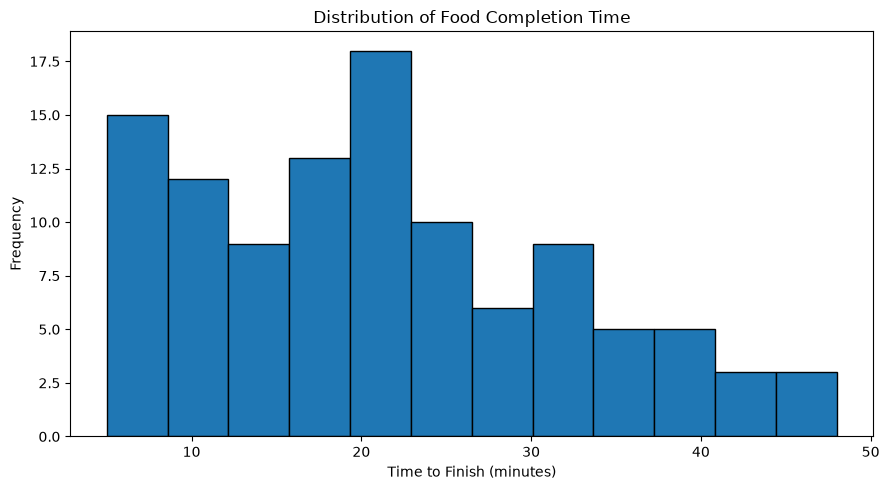

In [11]:
print(df["time_to_finish"].describe())

plt.figure(figsize=(9, 5))
plt.hist(df["time_to_finish"].dropna(), bins=12, edgecolor="black")
plt.xlabel("Time to Finish (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Food Completion Time")
plt.tight_layout()
plt.show()

### Outlier Analysis

In [12]:
target = df["time_to_finish"].dropna()
Q1 = target.quantile(0.25)
Q3 = target.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)

outliers = df[(df["time_to_finish"] < lower) | (df["time_to_finish"] > upper)]
outliers[["record_id", "date", "category", "participant_id", "crowd_level", "time_to_finish"]]

Q1: 12.75
Q3: 29.0
IQR: 16.25
Lower bound: -11.625
Upper bound: 53.375


,record_id,date,category,participant_id,crowd_level,time_to_finish


C:\Users\vkman\AppData\Local\Temp\ipykernel_24492\727384335.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["time_to_finish"].dropna(), vert=True)


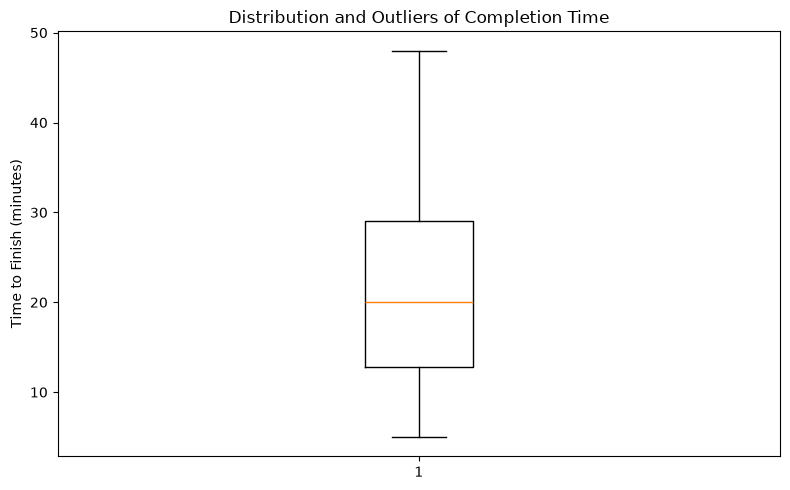

In [13]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["time_to_finish"].dropna(), vert=True)
plt.ylabel("Time to Finish (minutes)")
plt.title("Distribution and Outliers of Completion Time")
plt.tight_layout()
plt.show()

### Completion time by meal category

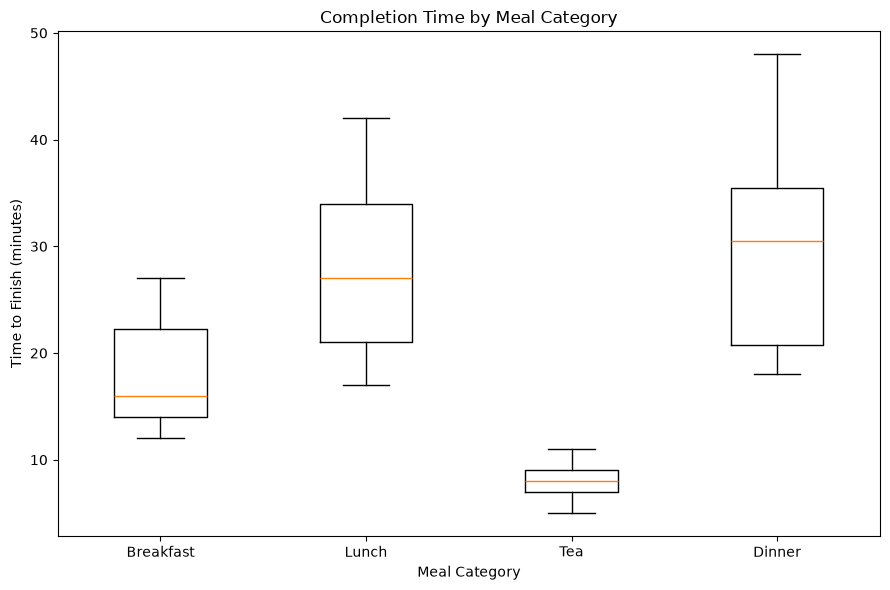

In [14]:
categories = ["Breakfast", "Lunch", "Tea", "Dinner"]
data = [df.loc[df["category"] == c, "time_to_finish"].dropna() for c in categories]

plt.figure(figsize=(9, 6))
plt.boxplot(data, tick_labels=categories)
plt.xlabel("Meal Category")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time by Meal Category")
plt.tight_layout()
plt.show()

category
Breakfast    18.107143
Lunch        28.037037
Tea           8.160000
Dinner       29.535714
Name: time_to_finish, dtype: float64


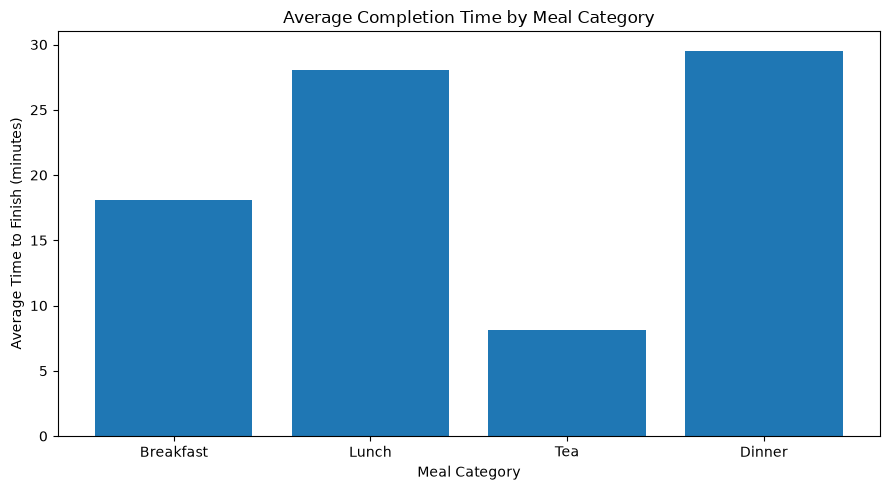

In [15]:
category_mean = df.groupby("category")["time_to_finish"].mean().reindex(categories)
print(category_mean)

plt.figure(figsize=(9, 5))
plt.bar(category_mean.index, category_mean.values)
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Meal Category")
plt.tight_layout()
plt.show()

### Completion time by crowd level

crowd_level
Low       14.500000
Medium    22.200000
High      33.636364
Name: time_to_finish, dtype: float64


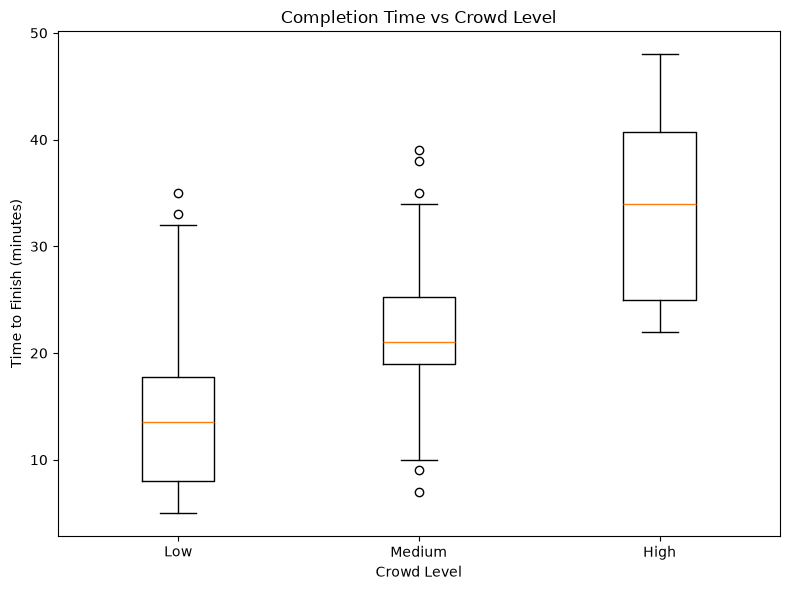

In [16]:
crowd_order = ["Low", "Medium", "High"]
crowd_mean = df.groupby("crowd_level")["time_to_finish"].mean().reindex(crowd_order)
print(crowd_mean)

data = [df.loc[df["crowd_level"] == c, "time_to_finish"].dropna() for c in crowd_order]
plt.figure(figsize=(8, 6))
plt.boxplot(data, tick_labels=crowd_order)
plt.xlabel("Crowd Level")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time vs Crowd Level")
plt.tight_layout()
plt.show()

### Completion time by day type

day_type
Weekday    21.028571
Weekend    21.391304
Holiday    22.066667
Name: time_to_finish, dtype: float64


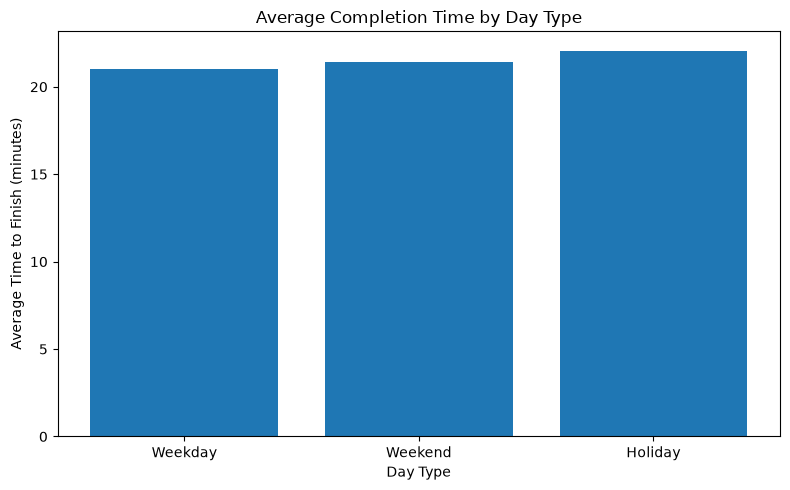

In [17]:
day_type_order = ["Weekday", "Weekend", "Holiday"]
day_type_mean = df.groupby("day_type")["time_to_finish"].mean().reindex(day_type_order)
print(day_type_mean)

plt.figure(figsize=(8, 5))
plt.bar(day_type_mean.index, day_type_mean.values)
plt.xlabel("Day Type")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Day Type")
plt.tight_layout()
plt.show()

### Completion time by participant

participant_id
P1    17.211538
P2    25.000000
Name: time_to_finish, dtype: float64


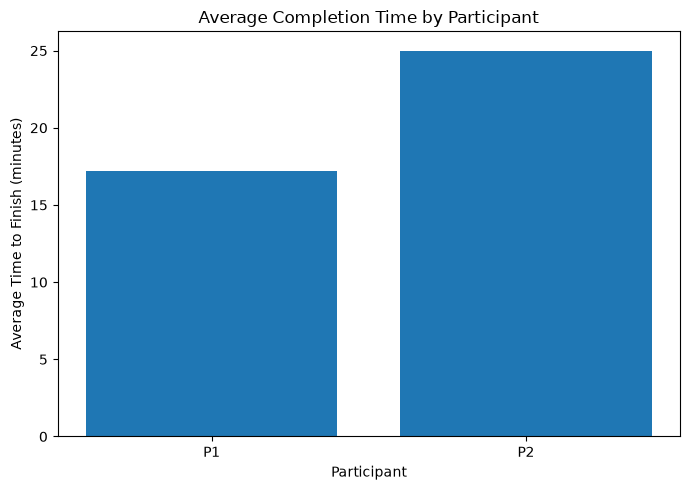

In [18]:
participant_mean = df.groupby("participant_id")["time_to_finish"].mean()
print(participant_mean)

plt.figure(figsize=(7, 5))
plt.bar(participant_mean.index, participant_mean.values)
plt.xlabel("Participant")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Participant")
plt.tight_layout()
plt.show()

### Participant and meal category

participant_id         P1         P2
category                            
Breakfast       14.214286  22.000000
Dinner          23.785714  35.285714
Lunch           20.769231  34.785714
Tea              8.454545   7.928571


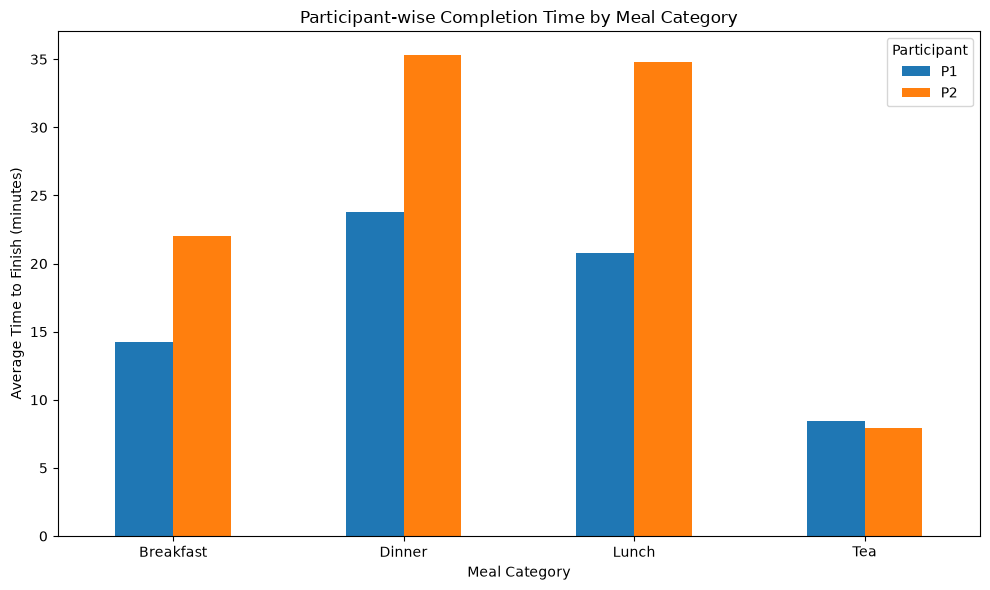

In [19]:
participant_category = (
    df.groupby(["category", "participant_id"])["time_to_finish"]
      .mean()
      .unstack()
)
print(participant_category)

participant_category.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Participant-wise Completion Time by Meal Category")
plt.xticks(rotation=0)
plt.legend(title="Participant")
plt.tight_layout()
plt.show()

### Time Taken against Different days for each Meal Type

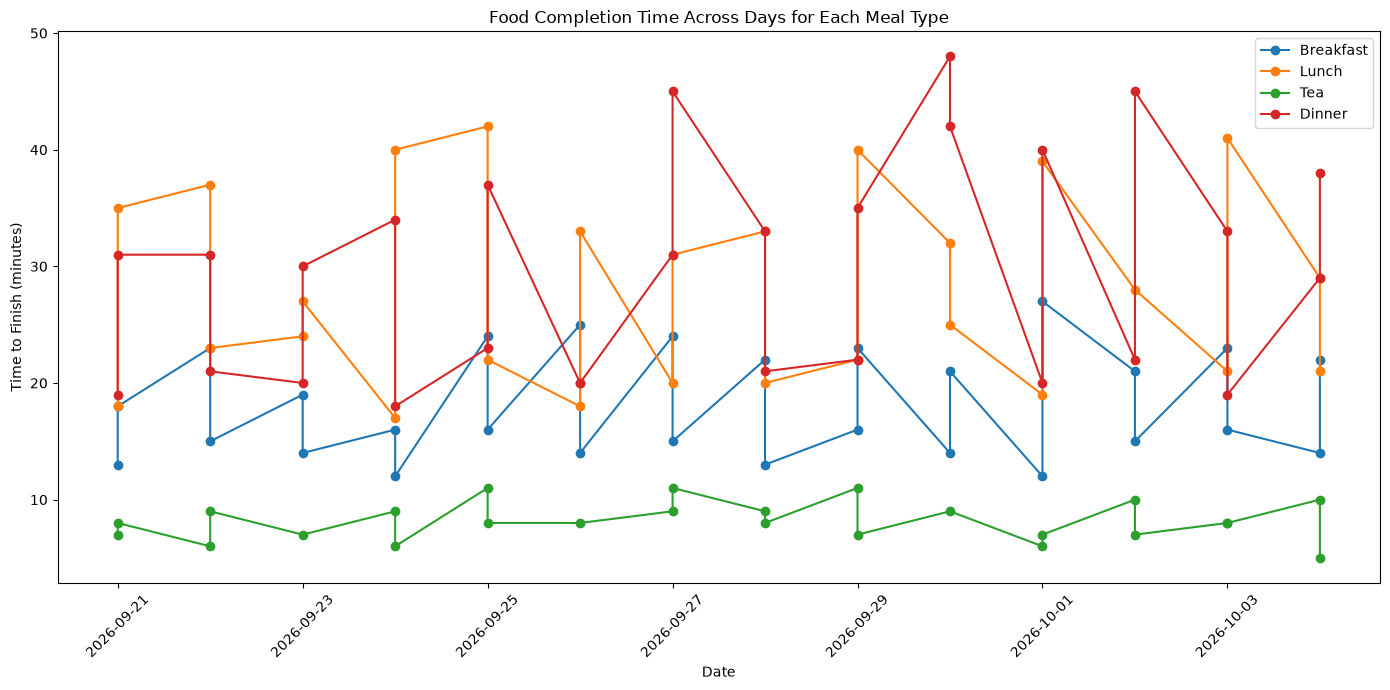

In [20]:
plot_df = df.dropna(subset=["date", "time_to_finish"]).sort_values("date")

plt.figure(figsize=(14, 7))
for category in categories:
    temp = plot_df[plot_df["category"] == category]
    plt.plot(temp["date"], temp["time_to_finish"], marker="o", linewidth=1.5, label=category)

plt.xlabel("Date")
plt.ylabel("Time to Finish (minutes)")
plt.title("Food Completion Time Across Days for Each Meal Type")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

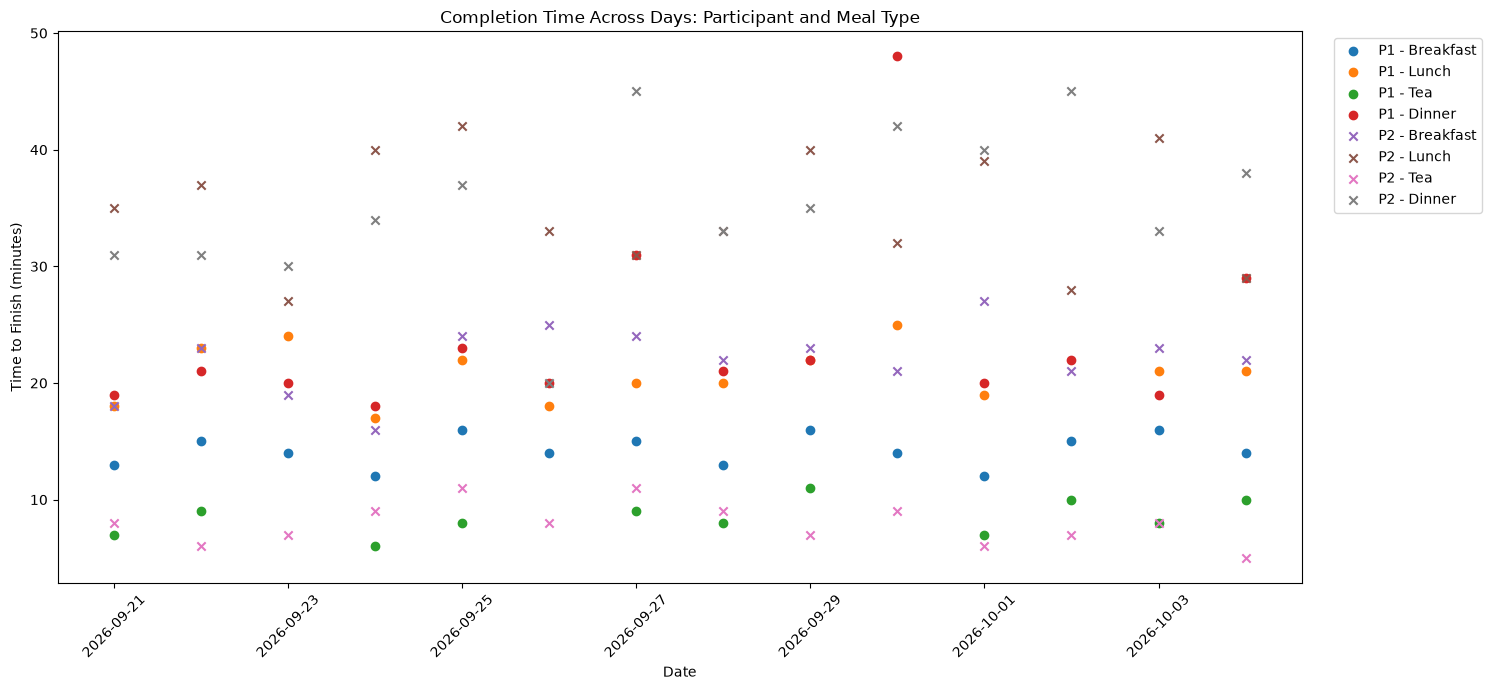

In [21]:
plt.figure(figsize=(15, 7))
markers = {"P1": "o","P2": "x"}
for participant in df["participant_id"].dropna().unique():
    for category in categories:
        temp = df[(df["participant_id"] == participant) & (df["category"] == category)].dropna(subset=["date", "time_to_finish"])
        plt.scatter(temp["date"], temp["time_to_finish"], marker=markers.get(participant, "o"), label=f"{participant} - {category}")
plt.xlabel("Date")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time Across Days: Participant and Meal Type")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Completion time by day of week

day
Monday       19.250000
Tuesday      21.312500
Wednesday    23.714286
Thursday     20.125000
Friday       22.066667
Saturday     20.466667
Sunday       22.125000
Name: time_to_finish, dtype: float64


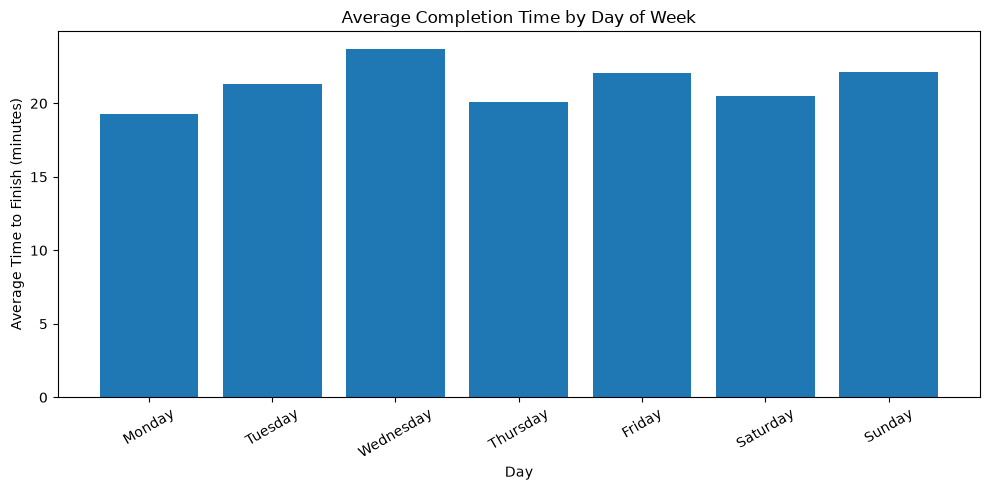

In [22]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_mean = df.groupby("day")["time_to_finish"].mean().reindex(day_order)
print(day_mean)

plt.figure(figsize=(10, 5))
plt.bar(day_mean.index, day_mean.values)
plt.xlabel("Day")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Average Completion Time by Day of Week")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Meal category and day

day        Monday  Tuesday  Wednesday  Thursday     Friday  Saturday  Sunday
category                                                                    
Breakfast    16.5    19.25       17.0     16.75  19.000000     19.50   18.75
Lunch        26.5    30.50       27.0     28.75  30.666667     28.25   25.25
Tea           8.0     8.25        8.0      7.00   9.000000      8.00    8.75
Dinner       26.0    27.25       35.0     28.00  31.750000     23.00   35.75


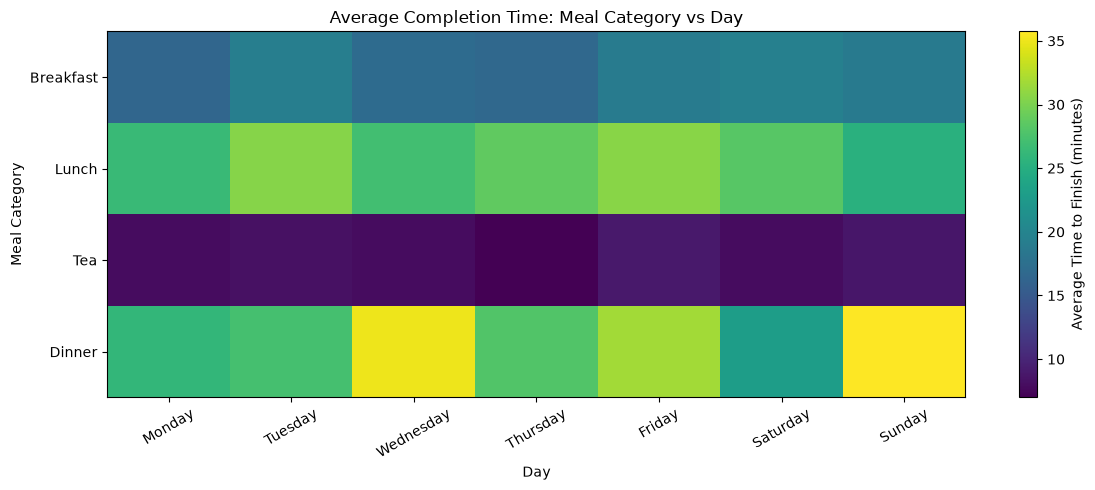

In [23]:
meal_day = (
    df.pivot_table(values="time_to_finish", index="category", columns="day", aggfunc="mean")
      .reindex(index=categories, columns=day_order)
)
print(meal_day)

plt.figure(figsize=(12, 5))
plt.imshow(meal_day, aspect="auto")
plt.colorbar(label="Average Time to Finish (minutes)")
plt.xticks(range(len(meal_day.columns)), meal_day.columns, rotation=30)
plt.yticks(range(len(meal_day.index)), meal_day.index)
plt.xlabel("Day")
plt.ylabel("Meal Category")
plt.title("Average Completion Time: Meal Category vs Day")
plt.tight_layout()
plt.show()

### Relation between waiting time and completion time

To examine whether longer waiting times are associated with longer completion times.

                waiting_min  time_to_finish
waiting_min        1.000000        0.660401
time_to_finish     0.660401        1.000000


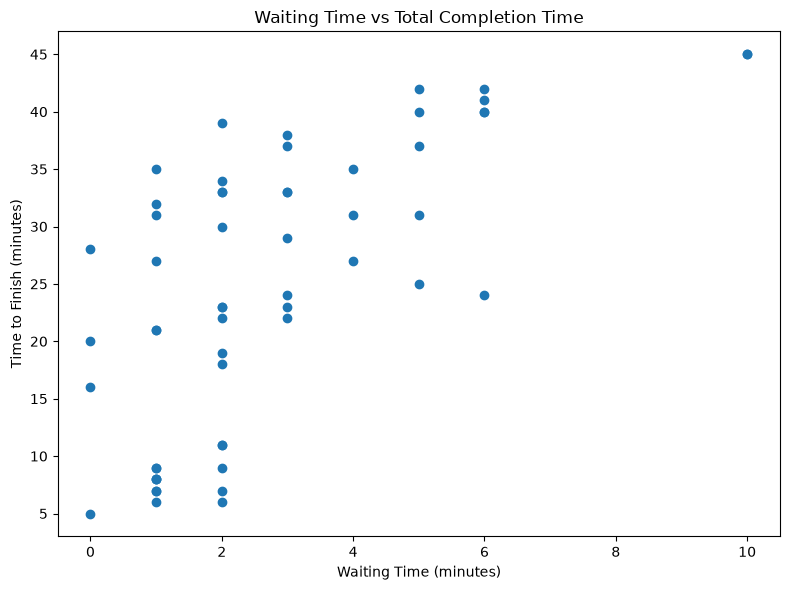

In [24]:
valid_waiting = df.dropna(subset=["waiting_min", "time_to_finish"])
print(valid_waiting[["waiting_min", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))

plt.scatter(
    valid_waiting["waiting_min"],
    valid_waiting["time_to_finish"]
)

plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Waiting Time vs Total Completion Time")

plt.tight_layout()
plt.show()

### Time of day

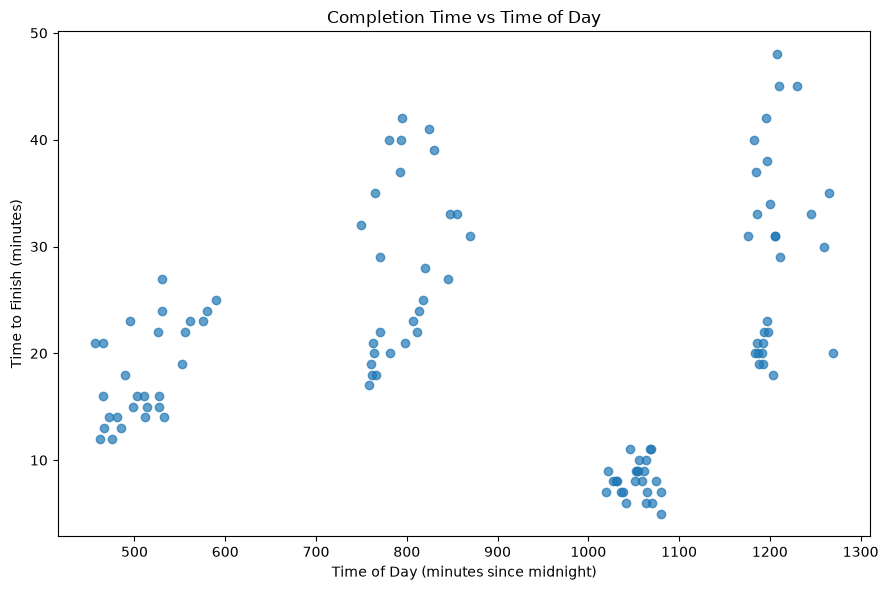

In [25]:
valid_time = df.dropna(subset=["time_minutes", "time_to_finish"])

plt.figure(figsize=(9, 6))
plt.scatter(valid_time["time_minutes"], valid_time["time_to_finish"], alpha=0.7)
plt.xlabel("Time of Day (minutes since midnight)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Completion Time vs Time of Day")
plt.tight_layout()
plt.show()

### Crowd level and completion time

                crowd_numeric  time_to_finish
crowd_numeric        1.000000        0.661569
time_to_finish       0.661569        1.000000


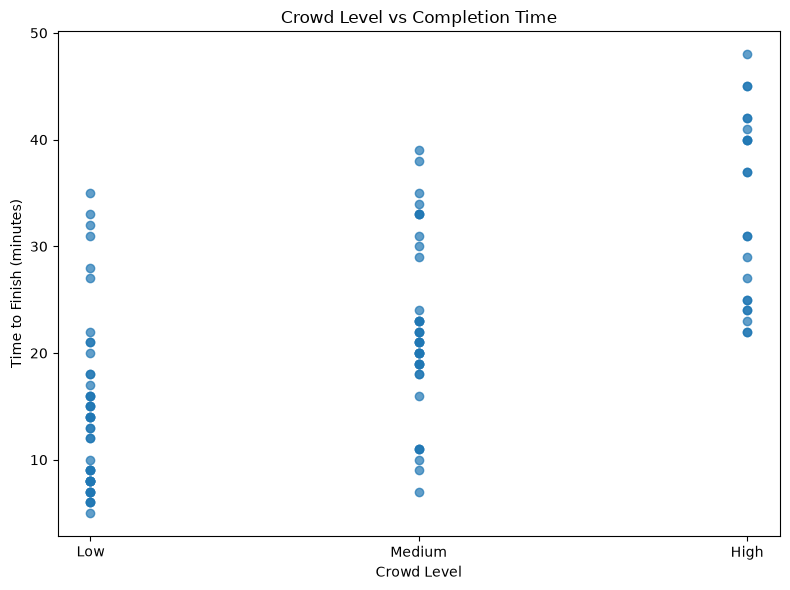

In [26]:
crowd_mapping = {"Low": 1, "Medium": 2, "High": 3}
df["crowd_numeric"] = df["crowd_level"].map(crowd_mapping)

print(df[["crowd_numeric", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))
plt.scatter(df["crowd_numeric"], df["time_to_finish"], alpha=0.7)
plt.xticks([1, 2, 3], ["Low", "Medium", "High"])
plt.xlabel("Crowd Level")
plt.ylabel("Time to Finish (minutes)")
plt.title("Crowd Level vs Completion Time")
plt.tight_layout()
plt.show()

### Meal category and crowd level

crowd_level       High        Low     Medium
category                                    
Breakfast    25.333333  15.611111  21.428571
Lunch        31.600000  25.500000  26.181818
Tea                NaN   7.631579   9.833333
Dinner       38.666667  29.333333  24.437500


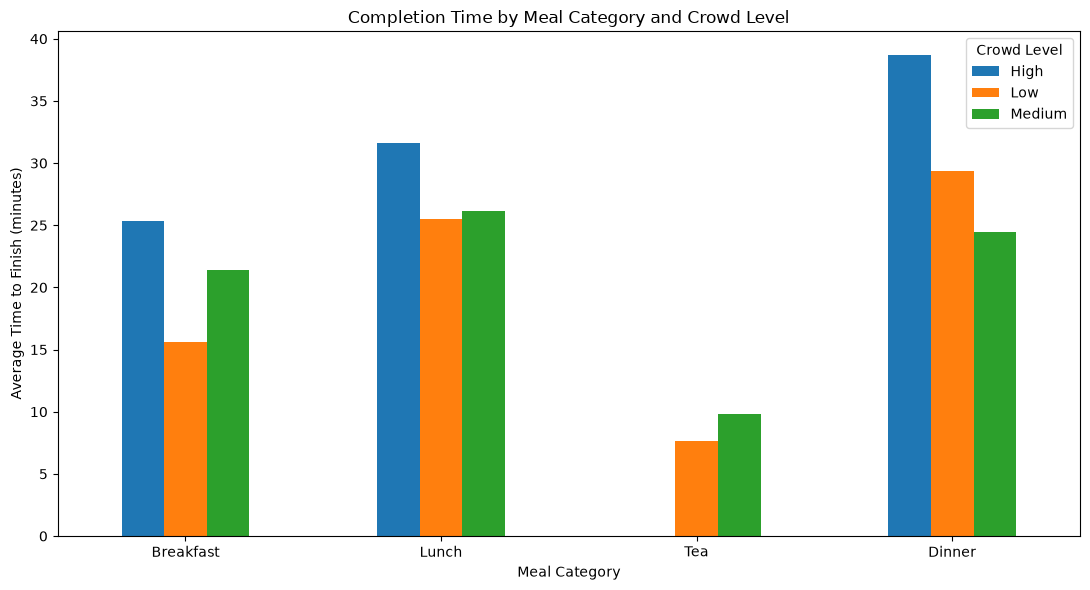

In [27]:
grouped = (
    df.groupby(["category", "crowd_level"])["time_to_finish"]
      .mean()
      .unstack()
      .reindex(categories)
)
print(grouped)

grouped.plot(kind="bar", figsize=(11, 6))
plt.xlabel("Meal Category")
plt.ylabel("Average Time to Finish (minutes)")
plt.title("Completion Time by Meal Category and Crowd Level")
plt.xticks(rotation=0)
plt.legend(title="Crowd Level")
plt.tight_layout()
plt.show()

### Waiting time

                waiting_min  time_to_finish
waiting_min        1.000000        0.660401
time_to_finish     0.660401        1.000000


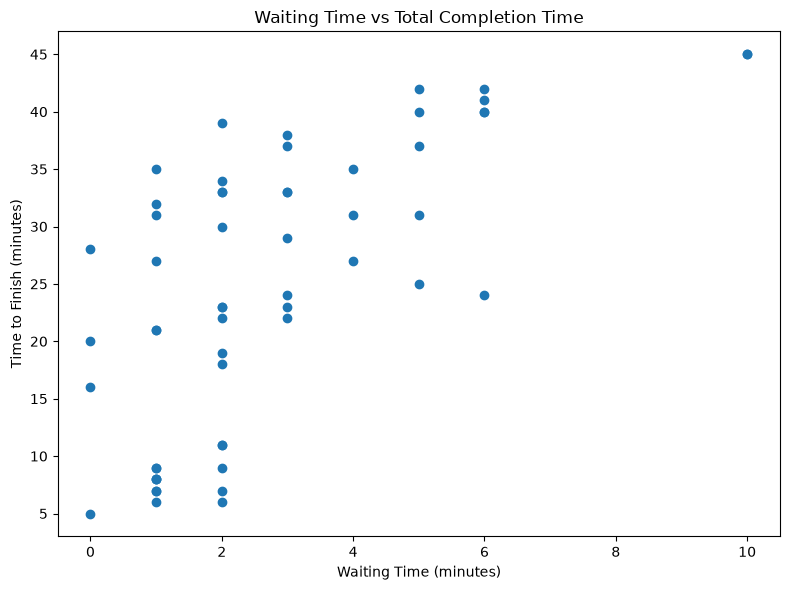

In [28]:
valid_waiting = df.dropna(subset=["waiting_min", "time_to_finish"])
print(valid_waiting[["waiting_min", "time_to_finish"]].corr())

plt.figure(figsize=(8, 6))
plt.scatter(valid_waiting["waiting_min"], valid_waiting["time_to_finish"])
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Time to Finish (minutes)")
plt.title("Waiting Time vs Total Completion Time")
plt.tight_layout()
plt.show()

In [29]:
time_anomalies = df[(df["time_minutes"] < 6 * 60) | (df["time_minutes"] > 23 * 60)]
time_anomalies[["record_id", "date", "day", "time", "category", "participant_id", "time_to_finish"]]

,record_id,date,day,time,category,participant_id,time_to_finish


### Summary

The main patterns observed in the exploratory analysis are summarized here before moving to the prediction stage

In [30]:
eda_summary = (
    df.groupby("category")["time_to_finish"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)
eda_summary

,count,mean,median,std,min,max
category,,,,,,
Breakfast,28,18.107143,16.0,4.540674,12.0,27.0
Dinner,28,29.535714,30.5,9.255557,18.0,48.0
Lunch,27,28.037037,27.0,8.159381,17.0,42.0
Tea,25,8.160000,8.0,1.650253,5.0,11.0


In [31]:
summary = pd.DataFrame({
    "Mean": df["time_to_finish"].mean(),
    "Median": df["time_to_finish"].median(),
    "Std Dev": df["time_to_finish"].std(),
    "Minimum": df["time_to_finish"].min(),
    "Maximum": df["time_to_finish"].max(),
    "Missing": df["time_to_finish"].isna().sum()
}, index=["Time to Finish"])

summary

,Mean,Median,Std Dev,Minimum,Maximum,Missing
Time to Finish,21.25,20.0,10.761757,5.0,48.0,4


## (b) Probabilistic Model and Parameter Estimation

The objective is to predict `time_to_finish`, which represents the number of minutes required to finish a meal. Since this is a positive continuous duration, we use a Gamma distribution to model the conditional distribution of the response.

The Gamma model parameters are estimated using Maximum Likelihood Estimation (MLE). The data is divided into 80% training data and 20% test data so that the fitted model can be evaluated on unseen observations

### Choice of Target Variable

The target variable is `time_to_finish`. It is a continuous variable measured in minutes and represents the duration taken by a participant to finish a meal.

The values are positive, so a probability distribution defined over positive values is appropriate for modeling the response.

### Imports

In [32]:
from scipy.special import gammaln
from scipy.optimize import minimize
from scipy.stats import gamma as gamma_dist

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [33]:
model_df = df[["time_minutes", "category", "crowd_level", "day_type", "participant_id", "time_to_finish"]].copy()
print("Number of observations:", len(model_df))
model_df.head()

Number of observations: 112


,time_minutes,category,crowd_level,day_type,participant_id,time_to_finish
0,485.0,Breakfast,Low,Weekday,P1,13.0
1,762.0,Lunch,Medium,Weekday,P1,18.0
2,1038.0,Tea,Low,Weekday,P1,7.0
3,1188.0,Dinner,Medium,Weekday,P1,19.0
4,498.0,Breakfast,Low,Weekday,P1,15.0


### Choice of Features

The features are selected based on variables that can reasonably influence the time taken to finish a meal.

- `time_minutes`: represents the time of day at which the meal is consumed.
- `category`: represents the meal type, such as Breakfast, Lunch, Tea, or Dinner.
- `crowd_level`: represents the level of crowd in the mess and may affect the meal experience.
- `day_type`: distinguishes weekdays, weekends, and holidays, which may be associated with different eating patterns.
- `participant_id`: captures differences between participants because individuals may have different typical completion times.

`record_id` is not used because it is only an identifier and does not provide meaningful information for predicting completion time.

### Handling Missing Values

Missing numerical values are replaced with their median values, while missing categorical values are replaced with their mode. The imputation values are calculated using the training data and then applied to both the training and test sets

In [34]:
X = model_df.drop(columns="time_to_finish")
y = model_df["time_to_finish"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11009)

The data is divided into 80% training data and 20% test data. The training data is used to estimate the model parameters, while the test data is kept separate for evaluating prediction performance on unseen observations.

In [35]:
median = X_train["time_minutes"].median()
X_train["time_minutes"] = X_train["time_minutes"].fillna(median)
X_test["time_minutes"] = X_test["time_minutes"].fillna(median)

y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_train.median())

for col in ["category","crowd_level","day_type","participant_id"]:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

### Encoding Categorical Variables

The variables `category`, `crowd_level`, `day_type`, and `participant_id` are categorical. They are converted into numerical dummy variables so that they can be included in the regression model.

One category from each variable is omitted and treated as the reference category. The coefficient of each remaining category therefore represents its effect relative to the corresponding reference category

In [36]:
X_train = pd.get_dummies(X_train,drop_first=True,dtype=float)
X_test = pd.get_dummies(X_test,drop_first=True,dtype=float)
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)

### Feature Scaling

The continuous variable `time_minutes` is standardized before fitting the model. This puts the numerical feature on a comparable scale and makes the magnitude of its estimated coefficient easier to interpret.

The dummy variables are already represented numerically and are not scaled

In [37]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[["time_minutes"]] = scaler.fit_transform(X_train[["time_minutes"]])
X_test_scaled[["time_minutes"]] = scaler.transform(X_test[["time_minutes"]])

feature_names = list(X_train_scaled.columns)
X_train_gamma = X_train_scaled.copy()
X_test_gamma = X_test_scaled.copy()
X_train_gamma.insert(0,"Intercept",1.0)
X_test_gamma.insert(0,"Intercept",1.0)
X_train_np = X_train_gamma.to_numpy(dtype=float)
X_test_np = X_test_gamma.to_numpy(dtype=float)
feature_names = list(X_train_gamma.columns)

print("Training matrix shape:",X_train_np.shape)
print("Testing matrix shape:",X_test_np.shape)

Training matrix shape: (89, 10)
Testing matrix shape: (23, 10)


### Choice of Probability Model

A Gamma distribution is used because `time_to_finish` is a positive continuous duration. From the lecture notes, we know that there is a direct association of duration variables with the Gamma distribution.

For an observation $i$,

$$
Y_i\mid X_i\sim Gamma(\alpha,\theta_i),
$$

where $\alpha$ is the shape parameter and $\theta_i$ is the scale parameter.

The conditional mean is

$$
\mu_i=E[Y_i\mid X_i]=\alpha\theta_i.
$$

We use a log link to model the mean:

$$
\log(\mu_i)=\beta_0+X_i^T\beta,
$$

so that

$$
\mu_i=\exp(\beta_0+X_i^T\beta).
$$

The exponential function guarantees that the predicted mean is positive

### Maximum Likelihood Estimation

The parameters of the Gamma regression model are estimated using Maximum Likelihood Estimation.

MLE selects the parameter values that make the observed training data most likely under the assumed Gamma model. The Gamma log-likelihood is maximized with respect to the regression coefficients and the shape parameter.

In [38]:
def negative_log_likelihood(params,X,y):
    beta = params[:-1]
    alpha = np.exp(params[-1])
    eta = np.clip(X @ beta,-20,20)
    mu = np.exp(eta)
    theta = mu / alpha
    log_likelihood = (alpha-1)*np.log(y)-y/theta-alpha*np.log(theta)-gammaln(alpha)
    return -np.sum(log_likelihood)

In [39]:
initial_beta = np.zeros(X_train_np.shape[1])
initial_alpha = 2.0
initial_params = np.append(initial_beta,np.log(initial_alpha))
print("Number of regression parameters:",len(initial_beta))
print("Initial shape parameter:",initial_alpha)

Number of regression parameters: 10
Initial shape parameter: 2.0


In [40]:
result = minimize(negative_log_likelihood,initial_params,args=(X_train_np,y_train.values),method="L-BFGS-B")
print("Optimization successful:",result.success)
print("Message:",result.message)
print("Negative log-likelihood:",result.fun)

Optimization successful: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Negative log-likelihood: 255.3564540930616


### Learned Parameters

The estimated coefficients determine how the expected completion time changes with the input variables

In [41]:
beta_hat = result.x[:-1]
alpha_hat = np.exp(result.x[-1])
parameter_table = pd.DataFrame({"Parameter":feature_names,"Estimate":beta_hat,"Effect":np.exp(beta_hat)})
print("Estimated Gamma shape parameter:",alpha_hat)
parameter_table

Estimated Gamma shape parameter: 20.22298395996784


,Parameter,Estimate,Effect
0,Intercept,1.816142,6.148091
1,time_minutes,-0.839175,0.432067
2,category_Dinner,2.568772,13.049790
3,category_Lunch,1.201605,3.325451
4,category_Tea,1.066871,2.906271
5,crowd_level_Low,-0.376336,0.686372
6,crowd_level_Medium,-0.268729,0.764351
7,day_type_Weekday,-0.015987,0.984140
8,day_type_Weekend,0.083707,1.087310
9,participant_id_P2,0.339219,1.403851


### Parameter Interpretation

The Gamma regression uses a log link:

$$
\log(\mu)=\beta_0+X^T\beta.
$$

Therefore, the multiplicative effect of a parameter is

$$
e^{\beta_j}.
$$

For a positive coefficient, $e^{\beta_j}>1$, indicating an increase in expected completion time relative to the reference category. For a negative coefficient, $e^{\beta_j}<1$, indicating a decrease

In [42]:
parameter_importance = parameter_table[parameter_table["Parameter"]!="Intercept"].copy()
parameter_importance["Absolute coefficient"] = parameter_importance["Estimate"].abs()
parameter_importance = parameter_importance.sort_values("Absolute coefficient",ascending=False)
parameter_importance

,Parameter,Estimate,Effect,Absolute coefficient
2,category_Dinner,2.568772,13.049790,2.568772
3,category_Lunch,1.201605,3.325451,1.201605
4,category_Tea,1.066871,2.906271,1.066871
1,time_minutes,-0.839175,0.432067,0.839175
5,crowd_level_Low,-0.376336,0.686372,0.376336
9,participant_id_P2,0.339219,1.403851,0.339219
6,crowd_level_Medium,-0.268729,0.764351,0.268729
8,day_type_Weekend,0.083707,1.087310,0.083707
7,day_type_Weekday,-0.015987,0.984140,0.015987


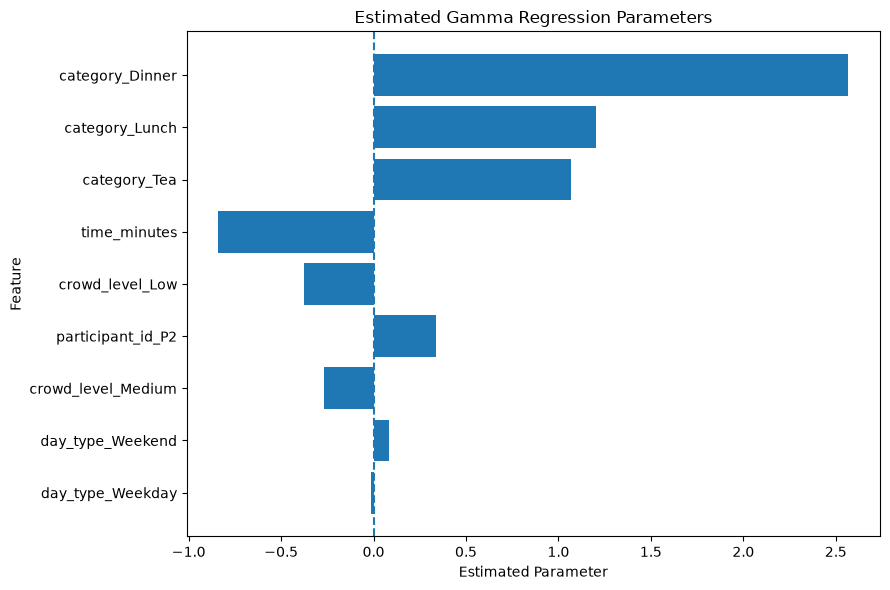

In [43]:
plt.figure(figsize=(9,6))
plt.barh(parameter_importance["Parameter"],parameter_importance["Estimate"])
plt.axvline(0,linestyle="--")
plt.xlabel("Estimated Parameter")
plt.ylabel("Feature")
plt.title("Estimated Gamma Regression Parameters")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

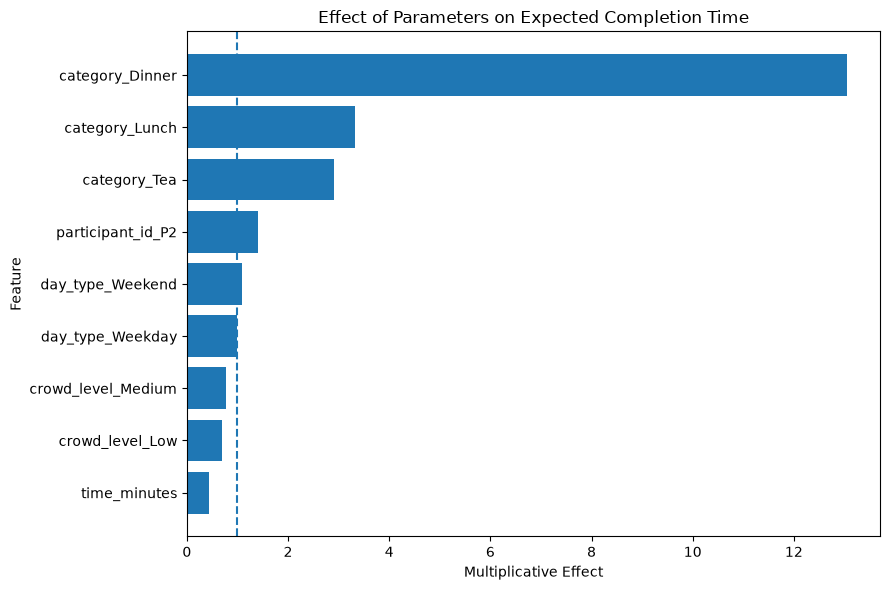

In [44]:
effect_plot = parameter_importance.sort_values("Effect")
plt.figure(figsize=(9,6))
plt.barh(effect_plot["Parameter"],effect_plot["Effect"])
plt.axvline(1,linestyle="--")
plt.xlabel("Multiplicative Effect")
plt.ylabel("Feature")
plt.title("Effect of Parameters on Expected Completion Time")
plt.tight_layout()
plt.show()

## (c) Prediction

The fitted Gamma regression model is used to predict `time_to_finish` for the 20% test set.

For comparison, a standard linear regression model is also fitted using the same training and test data. Linear regression assumes a Gaussian response with an identity link, whereas the Gamma model uses a Gamma response with a log link.

This comparison evaluates whether explicitly modeling the positive duration using a Gamma distribution improves prediction compared with the standard linear regression model

In [45]:
eta_test = np.clip(X_test_np @ beta_hat,-20,20)
gamma_predictions = np.exp(eta_test)

In [46]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)
linear_predictions = linear_model.predict(X_test_scaled)

### Evaluation

The two models are evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

MAE measures the average prediction error directly in minutes, making it easy to interpret how far the predictions are from the actual completion times. RMSE gives greater weight to larger errors because the errors are squared before averaging. Using both metrics provides a view of both the typical prediction error and the effect of larger prediction errors. Lower values indicate better predictive performance

In [47]:
gamma_mae = mean_absolute_error(y_test,gamma_predictions)
linear_mae = mean_absolute_error(y_test,linear_predictions)
gamma_rmse = np.sqrt(mean_squared_error(y_test,gamma_predictions))
linear_rmse = np.sqrt(mean_squared_error(y_test,linear_predictions))
print("Gamma Regression - MAE:",gamma_mae,"RMSE:",gamma_rmse)
print("Linear Regression - MAE:",linear_mae,"RMSE:",linear_rmse)

Gamma Regression - MAE: 2.484081934940192 RMSE: 3.2726875752253948
Linear Regression - MAE: 3.64156145282651 RMSE: 4.084002461313447


In [48]:
comparison = pd.DataFrame({"Model":["Gamma Regression","Linear Regression"],"MAE":[gamma_mae,linear_mae],"RMSE":[gamma_rmse,linear_rmse]})
comparison

,Model,MAE,RMSE
0,Gamma Regression,2.484082,3.272688
1,Linear Regression,3.641561,4.084002


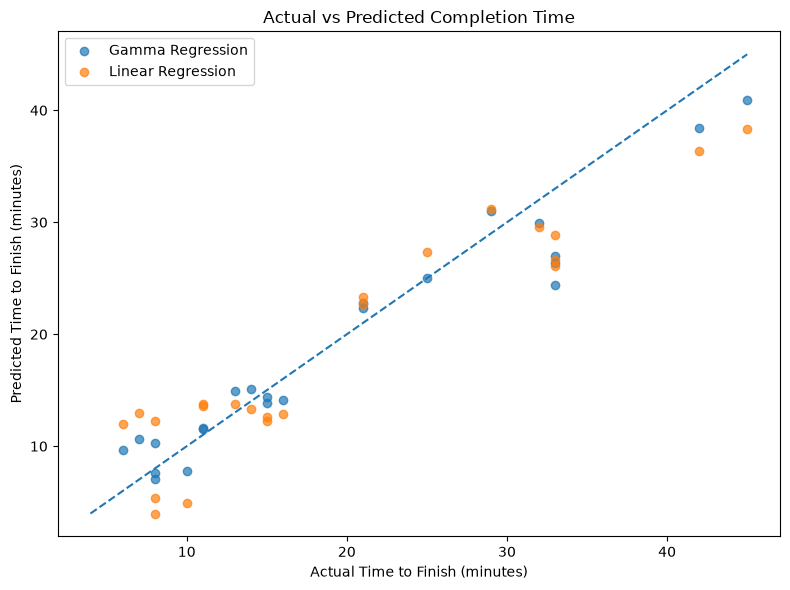

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,gamma_predictions,alpha=0.7,label="Gamma Regression")
plt.scatter(y_test,linear_predictions,alpha=0.7,label="Linear Regression")
min_value = min(y_test.min(),gamma_predictions.min(),linear_predictions.min())
max_value = max(y_test.max(),gamma_predictions.max(),linear_predictions.max())
plt.plot([min_value,max_value],[min_value,max_value],linestyle="--")
plt.xlabel("Actual Time to Finish (minutes)")
plt.ylabel("Predicted Time to Finish (minutes)")
plt.title("Actual vs Predicted Completion Time")
plt.legend()
plt.tight_layout()
plt.show()

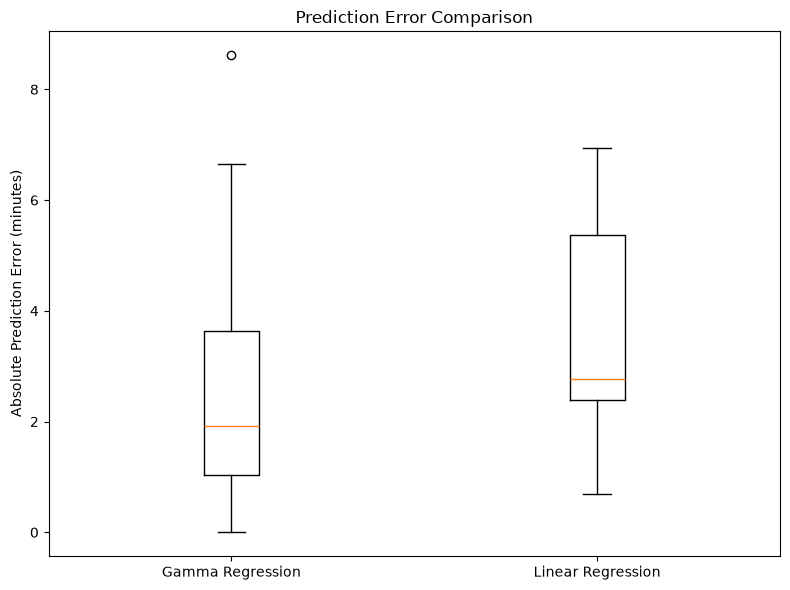

In [50]:
gamma_errors = np.abs(y_test.values-gamma_predictions)
linear_errors = np.abs(y_test.values-linear_predictions)
plt.figure(figsize=(8,6))
plt.boxplot([gamma_errors,linear_errors],tick_labels=["Gamma Regression","Linear Regression"])
plt.ylabel("Absolute Prediction Error (minutes)")
plt.title("Prediction Error Comparison")
plt.tight_layout()
plt.show()

### Prediction Results 

The Gamma model performs better than the standard linear regression model on both evaluation metrics. The Gamma model achieves an MAE of $2.48$ minutes and an RMSE of $3.27$ minutes, compared with an MAE of $3.64$ minutes and an RMSE of $4.08$ minutes for linear regression. The lower MAE indicates that the Gamma model produces smaller average prediction errors, while the lower RMSE indicates smaller overall squared prediction errors, including the effect of larger errors. This improvement is consistent with the nature of the target variable. `time_to_finish` is a positive continuous duration, for which the Gamma distribution is appropriate. In contrast, linear regression assumes a Gaussian response. The Gamma model also uses a log link, which models the expected completion time while ensuring positive predicted values. Overall, the Gamma regression achieves better predictive performance than linear regression on the held-out test set for both MAE and RMSE.

# Q2. Dimensionality Reduction using PCA on MNIST

## (a) PCA Theory: 

Given covariance matrix
$$
C = 
\begin{bmatrix}
0.25 & 0.20 \\
0.20 & 0.25 \\
\end{bmatrix}
$$

Find its eigenvalues and corresponding normalized eigenvectors. Identify the first principal component and calculate the percentage of total variance explained by it. Briefly explain how an input $x \in \mathbb{R}^{784}$ is projected onto a $k$-dimensional PCA space.


**Solution:** Handwritten solution can be found [here](data/Q2a.pdf)

## (b) 2D Representation of MNIST using PCA

The MNIST dataset contains $28 \times 28$ grayscale images of handwritten digits. Each image is represented as a $784$-dimensional vector. The pixel values are normalized to $[0, 1]$ before applying PCA.

Here, the first two principal components are used to represent the images in 2D.

In [51]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

### Load the MNIST Dataset

The MNIST dataset is stored in IDX format. The image files contain the $28 \times 28$ pixel values and the label files contain the corresponding digit labels.

In [52]:
# Path to MNIST dataset
DATA_DIR = Path("data/mnist")

train_images_path = DATA_DIR / "train-images.idx3-ubyte"
train_labels_path = DATA_DIR / "train-labels.idx1-ubyte"

test_images_path = DATA_DIR / "t10k-images.idx3-ubyte"
test_labels_path = DATA_DIR / "t10k-labels.idx1-ubyte"

print(train_images_path)
print(test_images_path)

data\mnist\train-images.idx3-ubyte
data\mnist\t10k-images.idx3-ubyte


In [53]:
def load_mnist_images(path):
    """Load MNIST images from an IDX3-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_images = int.from_bytes(f.read(4), byteorder="big")
        n_rows = int.from_bytes(f.read(4), byteorder="big")
        n_cols = int.from_bytes(f.read(4), byteorder="big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    images = data.reshape(n_images, n_rows * n_cols)
    return images

def load_mnist_labels(path):
    """Load MNIST labels from an IDX1-UBYTE file."""
    with open(path, "rb") as f:
        magic = int.from_bytes(f.read(4), byteorder="big")
        n_labels = int.from_bytes(f.read(4), byteorder="big")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [54]:
# Load training data
X_train = load_mnist_images(train_images_path)
y_train = load_mnist_labels(train_labels_path)

# Load test data
X_test = load_mnist_images(test_images_path)
y_test = load_mnist_labels(test_labels_path)

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 784)
Training labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


### Normalize Pixel Values

The original pixel values range from $0$ to $255$. They are divided by $255$ to bring them to the range $[0, 1]$.

In [55]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Apply PCA

PCA is fitted on the training data using the first two principal components.

In [56]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

print("Training PCA representation:", X_train_pca.shape)

Training PCA representation: (60000, 2)


### (i) Variance explained by PC1, PC2 and their cummulative variance

In [57]:
explained_variance = pca.explained_variance_ratio_

pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]
cumulative_variance = explained_variance.sum()

print(f"PC1 variance explained: {pc1_variance:.4f} ({pc1_variance * 100:.2f}%)")
print(f"PC2 variance explained: {pc2_variance:.4f} ({pc2_variance * 100:.2f}%)")
print(f"Cumulative variance: {cumulative_variance:.4f} ({cumulative_variance * 100:.2f}%)")

PC1 variance explained: 0.0970 (9.70%)
PC2 variance explained: 0.0710 (7.10%)
Cumulative variance: 0.1680 (16.80%)


### (ii) Project MNIST Test images onto the PCA Space

The PCA model fitted on the training data is used to project the test images into the same 2D space.

In [58]:
X_test_pca = pca.transform(X_test)

print("Test PCA representation:", X_test_pca.shape)

Test PCA representation: (10000, 2)


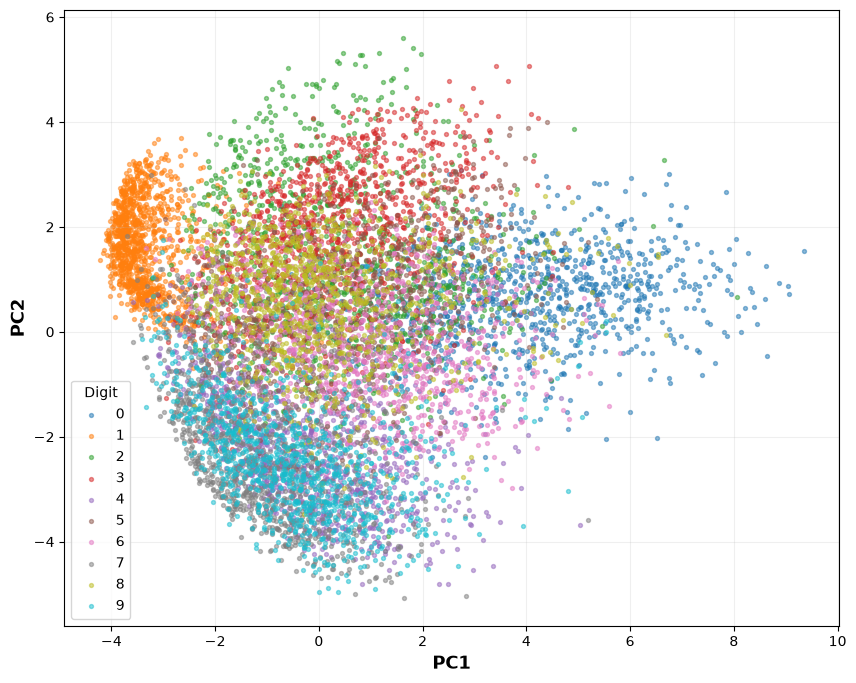

In [59]:
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_test == digit
    plt.scatter(X_test_pca[mask, 0], X_test_pca[mask, 1], s=8, alpha=0.5, label=str(digit))
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

### (iii) Selected Samples from Each Digit Class

200 test samples are selected from each digit class, giving 2000 samples in total. These samples are used for the reconstruction error, while 10 samples from each digit are shown in the reconstruction plots.

In [60]:
np.random.seed(11009)

samples_per_class = 200
selected_indices = []

for digit in range(10):
    indices = np.where(y_test == digit)[0]
    selected = np.random.choice(indices, size=samples_per_class, replace=False)
    selected_indices.extend(selected)
selected_indices = np.array(selected_indices)
X_selected = X_test[selected_indices]
y_selected = y_test[selected_indices]
X_selected_pca = X_test_pca[selected_indices]
print("Selected samples:", len(selected_indices))

Selected samples: 2000


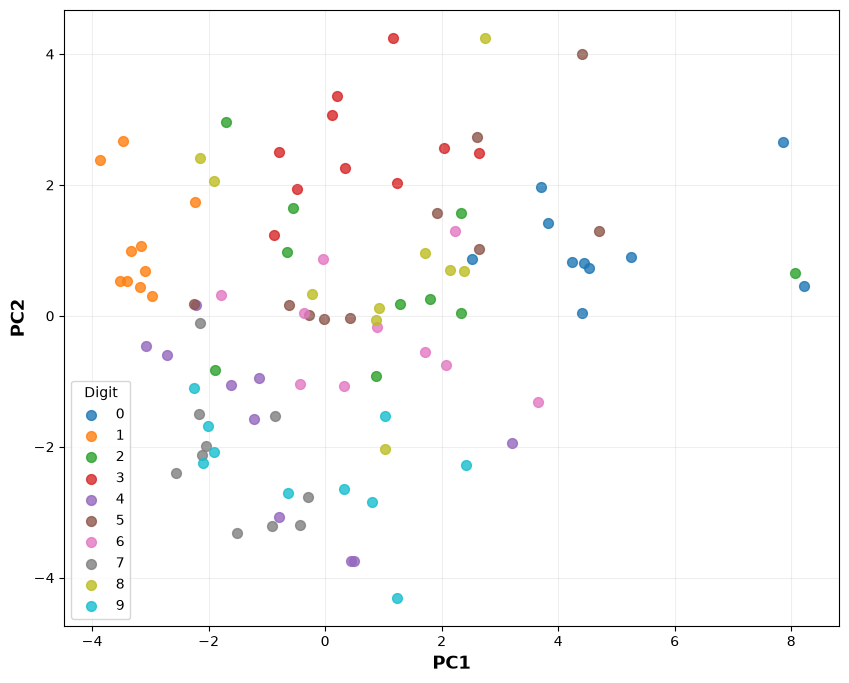

In [61]:
samples_to_plot = []
for digit in range(10):
    indices = np.where(y_selected == digit)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    samples_to_plot.extend(selected)
samples_to_plot = np.array(samples_to_plot)

X_plot_pca = X_selected_pca[samples_to_plot]
y_plot = y_selected[samples_to_plot]
plt.figure(figsize=(10, 8))

for digit in range(10):
    mask = y_plot == digit
    plt.scatter(X_plot_pca[mask, 0], X_plot_pca[mask, 1], s=50, alpha=0.8, label=str(digit))
plt.xlabel("PC1", fontsize=13, fontweight="bold")
plt.ylabel("PC2", fontsize=13, fontweight="bold")
plt.legend(title="Digit")
plt.grid(alpha=0.2)
plt.show()

#### Observations

The PCA plot shows that some digits are more separated than others. Digit 1 is relatively well separated from many of the other digits. There is more overlap among several of the other classes, especially for digits with similar shapes such as 2, 3, 5, 8, etc. This is expected because PCA uses the overall variation in the images and does not use the digit labels when finding the principal components.

### (iv) Reconstruction Using the First Two Principal Components

The 2000 selected test images are reconstructed using only PC1 and PC2. For each digit, 10 original images are shown together with their corresponding reconstructed images to compare the information that is retained and lost

In [62]:
X_original = X_selected.copy()
X_selected_pca = pca.transform(X_original)
X_reconstructed = pca.inverse_transform(X_selected_pca)
X_reconstructed = np.clip(X_reconstructed, 0, 1)

print("Original:", X_original.shape)
print("PCA:", X_selected_pca.shape)
print("Reconstructed:", X_reconstructed.shape)

Original: (2000, 784)
PCA: (2000, 2)
Reconstructed: (2000, 784)


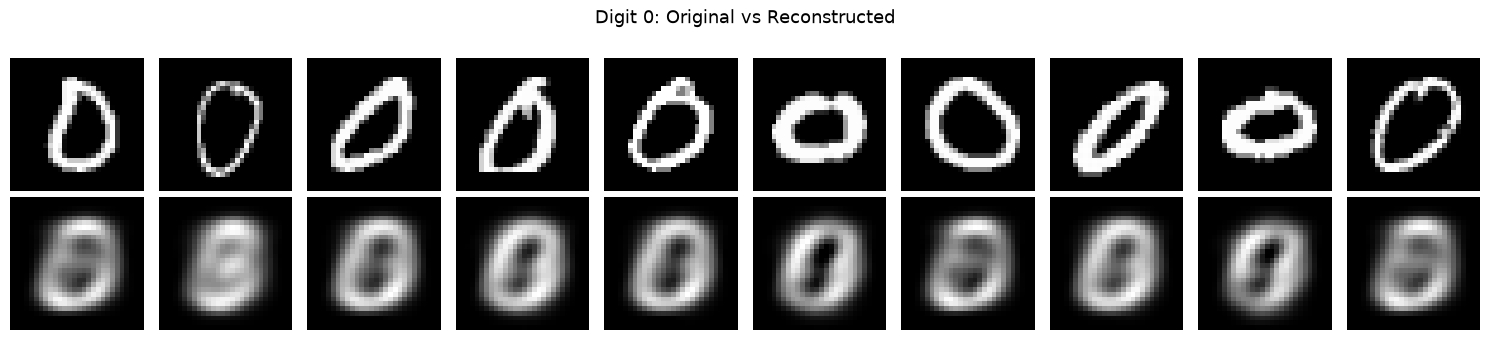

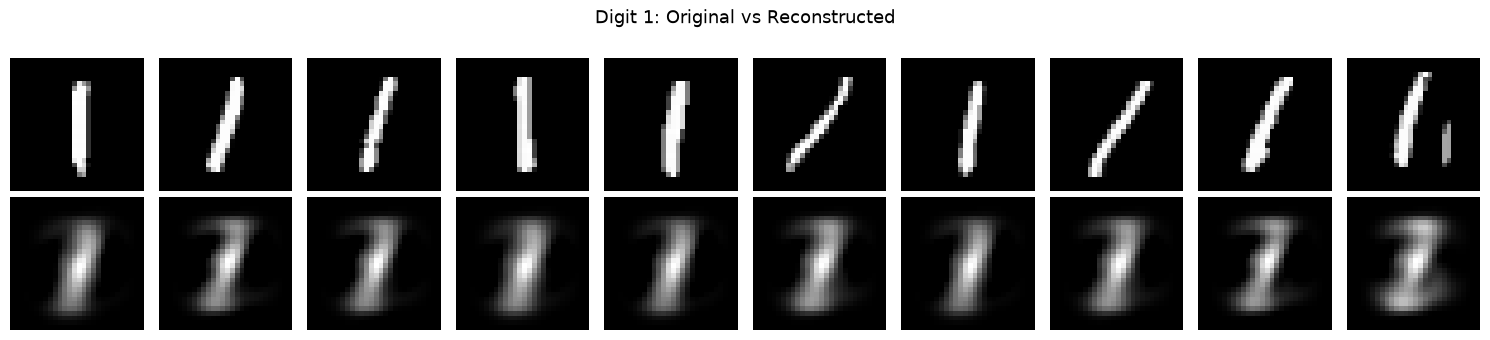

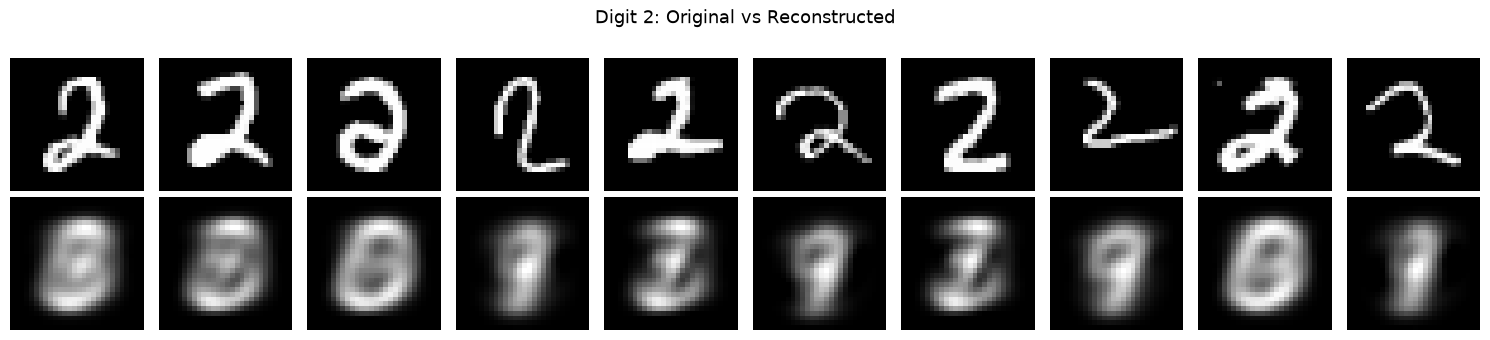

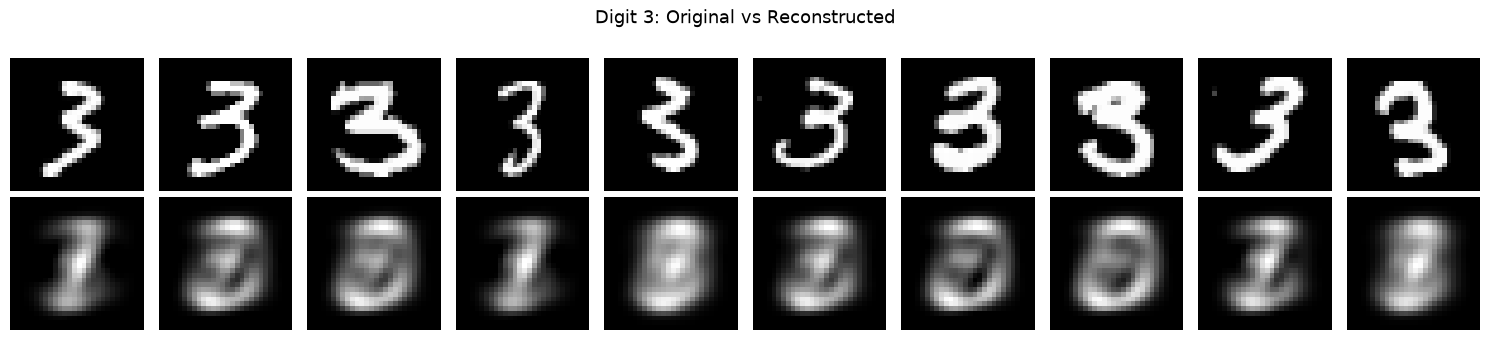

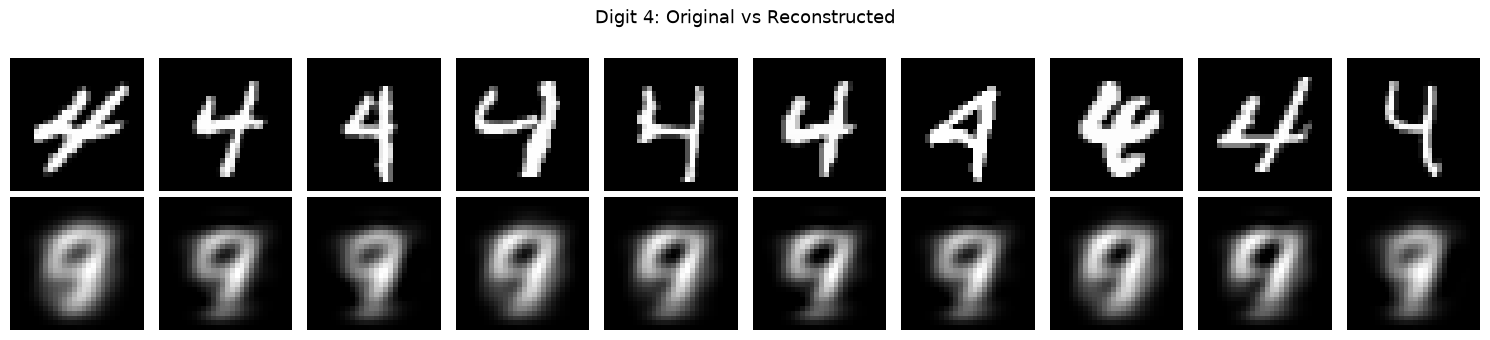

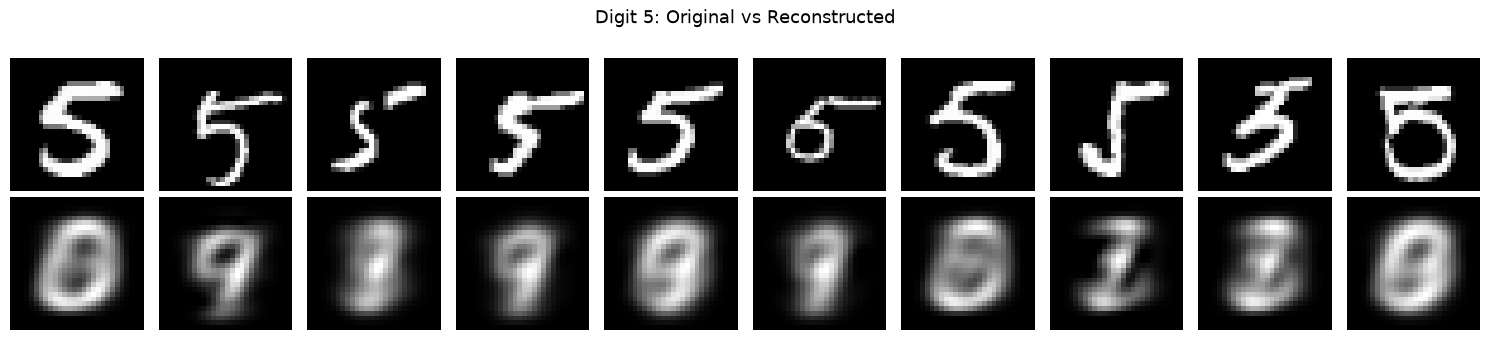

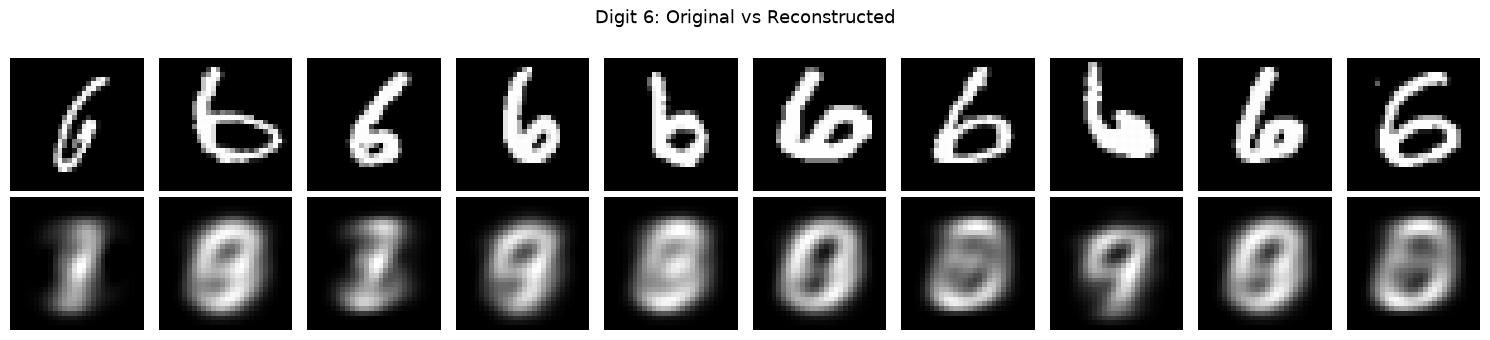

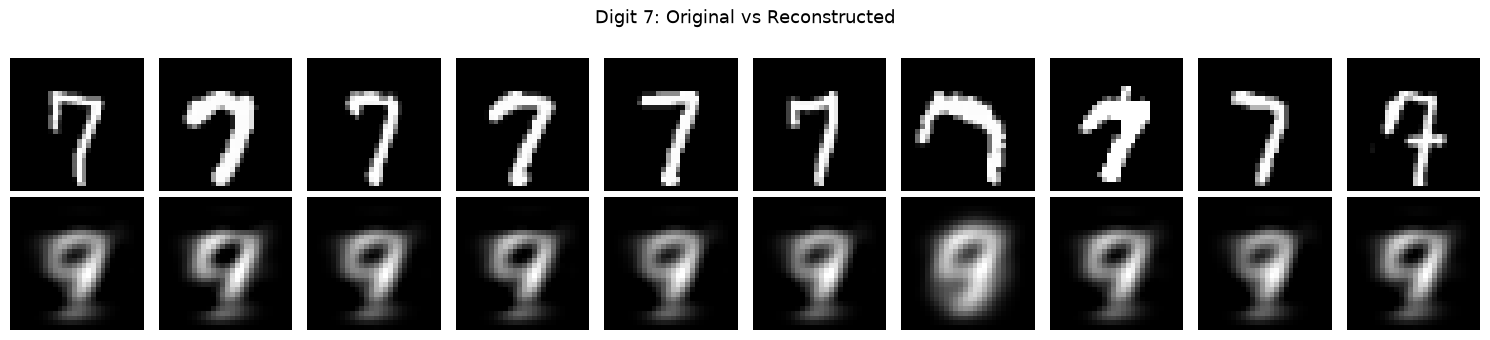

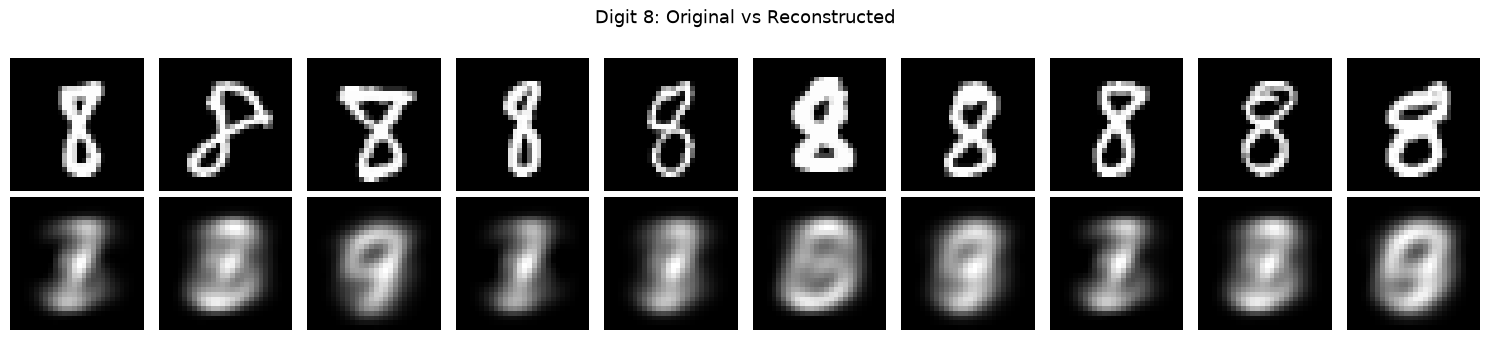

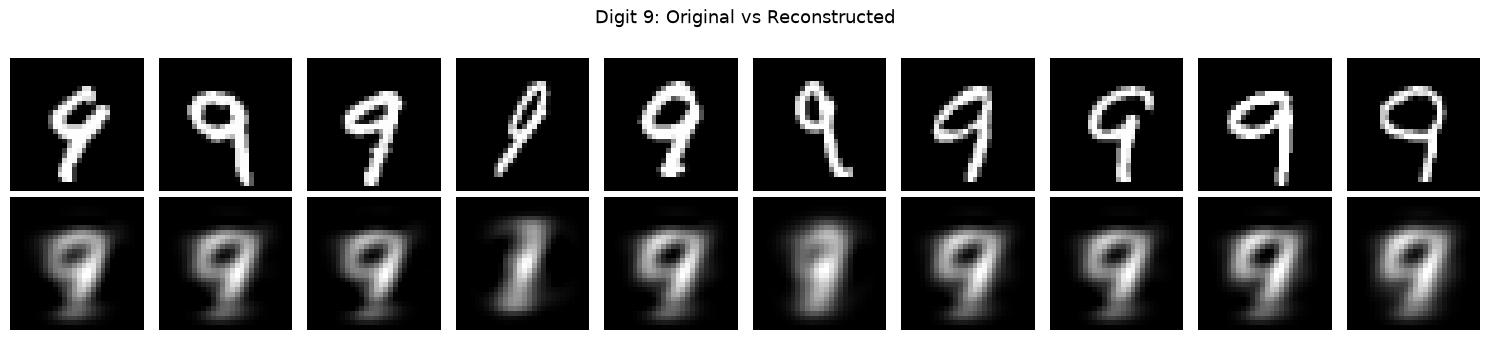

In [63]:
for digit in range(10):
    indices = np.where(y_selected == digit)[0]
    selected = np.random.choice(indices, size=10, replace=False)
    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    for j, idx in enumerate(selected):
        axes[0, j].imshow(X_original[idx].reshape(28, 28),cmap="gray")
        axes[0, j].axis("off")
        axes[1, j].imshow(X_reconstructed[idx].reshape(28, 28),cmap="gray")
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=11)
    fig.suptitle(f"Digit {digit}: Original vs Reconstructed",fontsize=13)
    plt.tight_layout()
    plt.show()

#### Reconstruction Discussion

The reconstructed images usually preserve the general shape of the digit, but they are much more blurred than the original images. Digit $1$ is generally easy to recognize after reconstruction, and many of the $0$'s are also recognizable. However, several samples from digits $2, 3, 4, 5, 6, 7, 8$ are not very clear and can look like other digits. Digit $4$ is particularly difficult to recognize in some of the reconstructed samples. This happens because only two principal components are used to reconstruct the original $784$-dimensional images, so a large amount of the image detail is lost.

In [64]:
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(X_selected, X_reconstructed)
print(f"Mean Squared Reconstruction Error: {reconstruction_error:.3f}")

Mean Squared Reconstruction Error: 0.056


## (c) Analysis and Interpretation

### (i) Class Separation and Overlap

The 2D PCA plot shows that some digit classes are more separated than others. Digit 1 is relatively well separated from many of the other classes. There is more overlap between several of the remaining digits, particularly among digits such as 2, 3, 5 and 8. This is because some digits have similar shapes and PCA is not trying to separate the classes. It only finds the directions with the highest variance in the data.

### (ii) Usefulness of the First Two Principal Components

PC1 explains $9.70\%$ of the variance and PC2 explains $7.10\%$, giving a cumulative explained variance of 16.80%. Even though the first two components capture only a small part of the total variance, they are still useful for visualization. They reduce the original 784 dimensions to two dimensions and allow the overall distribution and overlap between the digit classes to be seen in a single plot.

### (iii) Information Lost During Dimensionality Reduction

Using only two principal components means that $83.20\%$ of the variance is not represented in the 2D representation. The reconstruction plots show the effect of this information loss. The general shape of many digits is still present, but the reconstructed images are blurred and some individual digits are difficult to recognize. Digit 1 is generally preserved better, while several samples of digits 2, 3, 4, 5, 6, 7, and 8 are less clear. In particular, some reconstructed 4s look closer to 7s or 9s. The mean squared reconstruction error over the 2000 selected test images is 0.056, which also shows that a considerable amount of information is lost when the 784-dimensional images are represented using only two principal components.

# Q3. Ordinal Regression

## (a) Summary of [Ordinal Regression](https://www.jstor.org/stable/2984952)

Provide a brief summary of the paper. Explain how the likelihood and odds ratio for ordinal regression is different from multi-class classification. How is it different from the regression problems?

**Solution** Handwritten solution can be found [here](data/Q3a.pdf)

## (b) Parameter estimation for ordinal regression

Explain and derive the parameter estimation technique for the ordinal likelihood described in the paper.

**Solution** Handwritten solution can be found [here](data/Q3b.pdf)


## (c) Wine Quality Prediction using Ordinal Regression

The objective of this experiment is to predict wine quality using its physicochemical properties. Since the quality rating is ordered, I use ordinal logistic regression and compare it with linear regression. The dataset is divided into 80% training data and 20% testing data.

### Imports

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mord import LogisticAT, LogisticIT

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score

### Loading the dataset and basic exploration

In [66]:
red = pd.read_csv("data/wine/winequality-red.csv", sep=";")
white = pd.read_csv("data/wine/winequality-white.csv", sep=";")
red["wine_type"] = 0
white["wine_type"] = 1

wine = pd.concat([red, white], ignore_index=True)
print("Red wine:", red.shape)
print("White wine:", white.shape)

Red wine: (1599, 13)
White wine: (4898, 13)


In [67]:
wine = pd.concat([red, white], ignore_index=True)

print("Shape of dataset:", wine.shape)
print("\nColumns:")
print(wine.columns.tolist())

print("\nMissing values:")
print(wine.isnull().sum())

print("\nQuality distribution:")
print(wine["quality"].value_counts().sort_index())


Shape of dataset: (6497, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Quality distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


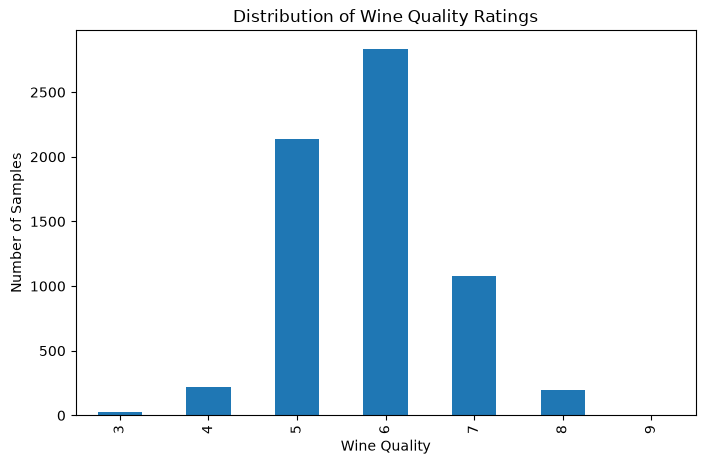

In [68]:
plt.figure(figsize=(8, 5))
wine["quality"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Samples")
plt.title("Distribution of Wine Quality Ratings")
plt.show()

The dataset does not contain any missing values. The quality ratings range from 3 to 9, with most observations having ratings of 5 or 6.

### Selecting Features and Target 

The 11 physicochemical measurements, together with a binary `wine_type` indicator distinguishing red and white wine, are used as input features, and `quality` is used as the target variable

In [69]:
features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "wine_type"
]

X = wine[features]
y = wine["quality"].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6497, 12)
y shape: (6497,)


### Train-Test Split

I use 80% of the data for training and 20% for testing. Stratified splitting is used to maintain a similar distribution of quality ratings in both sets.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=11009, stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5197
Testing samples: 1300


### Evaluation Metric
I use Mean Absolute Error (MAE) as the main evaluation metric because the target is an ordered rating. MAE measures the average difference between the actual and predicted quality ratings. RMSE is also reported for comparison.

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

### Feature Standardization
The features are standardized before training because they have different ranges. The scaler is included in the model pipeline to avoid data leakage during cross-validation.

### Ordinal Logistic Regression
I use `LogisticAT` from the `mord` package for ordinal regression. The regularization parameter `alpha` is selected using 5-fold cross-validation.

In [71]:
ordinal_pipeline = Pipeline([("scaler", StandardScaler()), ("model", LogisticAT(max_iter=10000))])
param_grid = {"model__alpha": [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11009)
ordinal_grid = GridSearchCV(estimator=ordinal_pipeline, param_grid=param_grid, 
                            scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
ordinal_grid.fit(X_train, y_train)

print("Best alpha:", ordinal_grid.best_params_["model__alpha"])
print("Best 5-fold CV MAE:", -ordinal_grid.best_score_)

d:\PhD\Coursework\CS5590_FoML\Assignments\Assignment1\foml1\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best alpha: 0.0001
Best 5-fold CV MAE: 0.5183758421559193


The best cross-validation result was obtained with `alpha = 0.0001`, giving a mean 5-fold cross-validation MAE of approximately $0.5184$. The differences between the tested regularization values are very small, indicating that model performance is relatively insensitive to `alpha` over the tested range. The value `alpha = 0.0001` selected by `GridSearchCV` is therefore used for the final ordinal regression model.

In [72]:
best_ordinal_model = ordinal_grid.best_estimator_
y_pred_ordinal = best_ordinal_model.predict(X_test)
ordinal_mae = mean_absolute_error(y_test, y_pred_ordinal)
ordinal_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ordinal))

print("Ordinal Regression Results")
print("--------------------------")
print("MAE :", ordinal_mae)
print("RMSE:", ordinal_rmse)

Ordinal Regression Results
--------------------------
MAE : 0.49923076923076926
RMSE: 0.7829922880060334


### Ordinal Regression Predictions

The ordinal regression model predicts discrete quality ratings. I compare the predicted ratings with the actual ratings to examine the model's performance.

In [73]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred_ordinal.astype(int)})
comparison.head()

,Actual,Predicted
0,6,5
1,5,5
2,7,6
3,6,6
4,6,6


In [74]:
ordinal_confusion = pd.crosstab(comparison["Actual"], comparison["Predicted"], 
                                rownames=["Actual"], colnames=["Predicted"])
ordinal_confusion

Predicted,5,6,7
Actual,,,
3,3,2,1
4,31,11,1
5,228,198,2
6,88,442,37
7,13,154,49
8,0,29,10
9,0,0,1


### Linear Regression

As a baseline, I use linear regression with the same training and testing data. Unlike ordinal regression, linear regression treats quality as a continuous numerical variable.

In [75]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_linear = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)

Linear Regression Results
-------------------------
MAE : 0.5634083895726867
RMSE: 0.7300524969404064


### Model Comparison

The ordinal regression model achieves a lower MAE than linear regression, while linear regression achieves lower RMSE. Since MAE is the main metric for this ordinal prediction problem, the ordinal regression model performs better according to the selected metric.

In [76]:
results = pd.DataFrame({
    "Model": ["Ordinal Regression", "Linear Regression"],
    "MAE": [ordinal_mae, linear_mae],
    "RMSE": [ordinal_rmse, linear_rmse],
})

results

,Model,MAE,RMSE
0,Ordinal Regression,0.499231,0.782992
1,Linear Regression,0.563408,0.730052


For MAE and RMSE, a lower value is better. MAE is used as the main metric because it is easy to interpret for an ordinal rating. The ordinal regression model has an MAE of approximately 0.50, meaning that its predicted quality ratings differ from the actual ratings by about half a quality point on average.

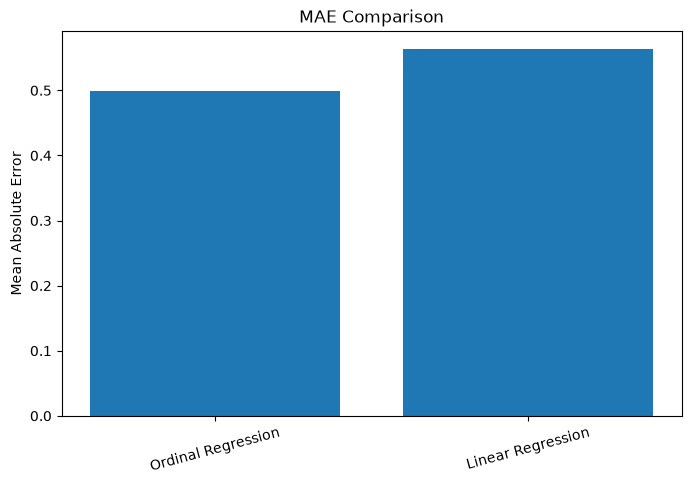

In [77]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["MAE"])
plt.ylabel("Mean Absolute Error")
plt.title("MAE Comparison")
plt.xticks(rotation=15)
plt.show()

### Actual vs Predicted Quality

The plot shows the relationship between the actual quality ratings and the ratings predicted by the ordinal regression model.

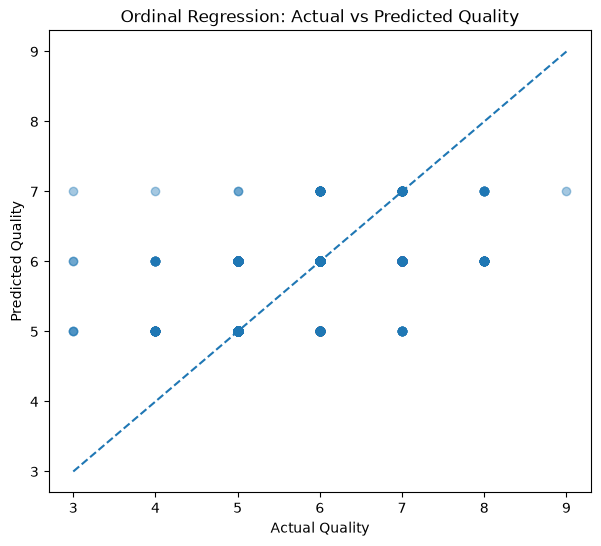

In [78]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ordinal, alpha=0.4)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Ordinal Regression: Actual vs Predicted Quality")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

### Prediction Errors

The distribution of prediction errors shows how far the ordinal regression predictions are from the actual quality ratings.

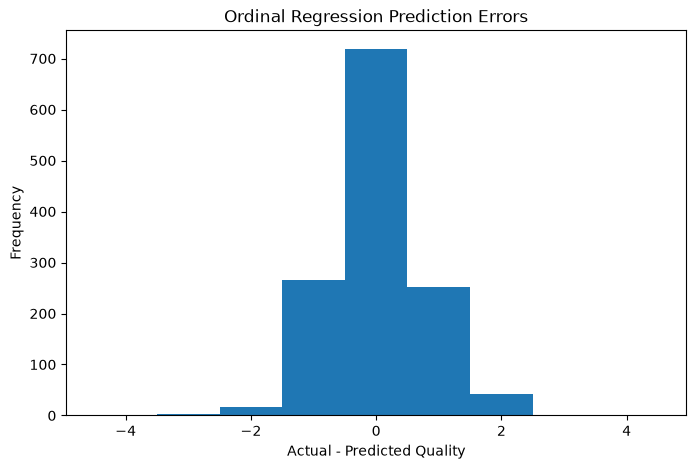

In [79]:
ordinal_errors = y_test.values - y_pred_ordinal.astype(int)

plt.figure(figsize=(8, 5))
plt.hist(ordinal_errors, bins=np.arange(-4.5, 5.5, 1))
plt.xlabel("Actual - Predicted Quality")
plt.ylabel("Frequency")
plt.title("Ordinal Regression Prediction Errors")
plt.show()

### Final Results 

The final test-set results are compared below. The ordinal regression model obtains an MAE of $0.4992$, compared with $0.5634$ for linear regression. This means that the ordinal model makes smaller errors on average according to the primary evaluation metric. The ordinal regression RMSE is $0.7830$, while linear regression obtains an RMSE of $0.7301$.

In [80]:
cv_results = pd.DataFrame(ordinal_grid.cv_results_)
cv_results[["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score")

,param_model__alpha,mean_test_score,std_test_score,rank_test_score
0,0.0001,-0.518376,0.012806,1
1,0.0003,-0.518376,0.012806,1
2,0.0010,-0.518376,0.012806,1
3,0.0030,-0.518376,0.012806,1
4,0.0100,-0.518376,0.012806,1
5,0.0300,-0.518376,0.012806,1
6,0.1000,-0.518376,0.012806,1
8,1.0000,-0.518376,0.013021,1
7,0.3000,-0.518568,0.012774,9


In [81]:
cv_summary = cv_results[["param_model__alpha", "mean_test_score", "std_test_score", "rank_test_score"]].copy()
cv_summary["mean_CV_MAE"] = -cv_summary["mean_test_score"]
cv_summary["std_CV_MAE"] = cv_summary["std_test_score"]
cv_summary = cv_summary[["param_model__alpha", "mean_CV_MAE", "std_CV_MAE", "rank_test_score"]].sort_values("mean_CV_MAE")
cv_summary

,param_model__alpha,mean_CV_MAE,std_CV_MAE,rank_test_score
0,0.0001,0.518376,0.012806,1
1,0.0003,0.518376,0.012806,1
2,0.0010,0.518376,0.012806,1
3,0.0030,0.518376,0.012806,1
4,0.0100,0.518376,0.012806,1
5,0.0300,0.518376,0.012806,1
6,0.1000,0.518376,0.012806,1
8,1.0000,0.518376,0.013021,1
7,0.3000,0.518568,0.012774,9


In [82]:
final_comparison = pd.DataFrame({
    "Model": ["Ordinal Regression", "Linear Regression"],
    "MAE": [ordinal_mae, linear_mae],
    "RMSE": [ordinal_rmse, linear_rmse],
})
final_comparison

,Model,MAE,RMSE
0,Ordinal Regression,0.499231,0.782992
1,Linear Regression,0.563408,0.730052


### Conclusion

The ordinal regression model achieved an MAE of $0.4992$ on the test set, compared with $0.5634$ for linear regression. Since wine quality is an ordered variable, MAE is a suitable primary metric because it measures how far the predicted quality is from the actual quality while preserving the ordering of the ratings. Based on MAE, the ordinal regression model performs better.

However, linear regression achieved a lower RMSE of $0.7301$, compared with $0.7830$ for ordinal regression. One reason for this is that linear regression produces continuous predictions, such as $5.6$ or $6.2$, which can be numerically closer to the actual quality score than the integer-valued predictions produced by the ordinal model. Since RMSE gives greater weight to larger errors, these smaller numerical differences can result in a lower RMSE for linear regression.

The results are also affected by the imbalance in the wine-quality dataset. Most of the samples belong to the middle quality ratings, particularly 5 and 6, while very few samples belong to the extreme ratings such as 3, 8, and especially 9. As a result, the ordinal model tends to predict the more frequently occurring middle classes and has limited opportunity to learn reliable patterns for the less represented quality levels. Data augmentation or other techniques for handling class imbalance could potentially improve the model's ability to predict these less frequent classes, but investigating such techniques is outside the scope of this study.

Overall, the ordinal regression model is the more appropriate choice for this problem because wine quality is an ordered categorical variable, and it achieves a lower MAE than linear regression. The lower RMSE of linear regression shows that continuous predictions can still provide better numerical accuracy under a squared-error metric. Therefore, the results highlight the trade-off between using a model that appropriately captures the ordinal nature of the target and one that can produce more precise continuous predictions.

# Q4. Heteroscedastic Least Squares

## (a) Likelihood and prior
Derive the expression of likelihood and prior for a heteroscedastic setting for a single data point with input $x_n$ and output $t_n$.

## (b) Objective functions
Provide the expression for the objective function that you will consider for the ML and MAP estimation of the parameters considering a data set of size $N$.

## (c)  Proof
Show that the ML objective results in each data point $t_n$ being associated with a weighting factor $r_n > 0$, such that the sum-of-squares error function becomes

$$
E_D(\mathbf{w}) =
\frac{1}{2}\sum_{n=1}^{N}
r_n\left\{t_n-\mathbf{w}^{T}\boldsymbol{\phi}(x_n)\right\}^{2}.
$$

Find an expression for $\mathbf{w}$ that minimizes this error function.



**Solution:** The complete handwritten solution of Q4 can be found [here](data/Q4.pdf)

# Q5. Logistic Regression

## (a) Newton-Raphson Optimization
Provide the expressions for the gradient, Hessian, and update equations for the Newton-Raphson optimization technique used to obtain the parameters in the logistic regression model. Provide an algorithm describing the methodology.

## (b) Relation to Weighted Least Squares
Show that the Newton-Raphson update scheme is related to the weighted least squares problem described in Question 4(c) and explain why it is called the Iteratively Reweighted Least Squares method.

## (c) Convexity
Show that the error function of logistic regression is a convex function of \(\mathbf{w}\) and hence has a unique minimum with the help of the Hessian matrix.



**Solution:** The complete handwritten solution of Q5 can be found [here](data/Q5.pdf)